In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata

# 1st Dataset Check

source: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

## Data Load

In [4]:
csv_files = [
    "olist_customers_dataset.csv",
    "olist_geolocation_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_orders_dataset.csv",
    "olist_products_dataset.csv",
    "olist_sellers_dataset.csv",
    "product_category_name_translation.csv"
]

dfs = {}
for file_name in csv_files:
    df_name = file_name.replace('.csv', '')
    print(f"Loading {file_name}...")
    dfs[df_name] = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "olistbr/brazilian-ecommerce",
        file_name
    )
    print(f"Loaded {df_name} with {len(dfs[df_name])} rows.")

Loading olist_customers_dataset.csv...
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Loaded olist_customers_dataset with 99441 rows.
Loading olist_geolocation_dataset.csv...
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Loaded olist_geolocation_dataset with 1000163 rows.
Loading olist_order_items_dataset.csv...
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Loaded olist_order_items_dataset with 112650 rows.
Loading olist_order_payments_dataset.csv...
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Loaded olist_order_payments_dataset with 103886 rows.
Loading olist_order_reviews_dataset.csv...
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Loaded olist_order_reviews_dataset with 99224 rows.
Loading olist_orders_dataset.csv...
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Loaded olist_orders_dataset with 99441 rows.
Loading ol

In [5]:
print("All loaded DataFrames:", dfs.keys())

All loaded DataFrames: dict_keys(['olist_customers_dataset', 'olist_geolocation_dataset', 'olist_order_items_dataset', 'olist_order_payments_dataset', 'olist_order_reviews_dataset', 'olist_orders_dataset', 'olist_products_dataset', 'olist_sellers_dataset', 'product_category_name_translation'])


## Data Cleaning

In [6]:
#check datatype
def check_data_types(dataframe, columns):
    print(f"\n--- Checking Data Types for DataFrame: {dataframe.name} ---")
    for col in columns:
        print(f"Column '{col}': {dataframe[col].dtype}")


for df_name, df in dfs.items():
    df.name = df_name
    check_data_types(df, df.columns)


--- Checking Data Types for DataFrame: olist_customers_dataset ---
Column 'customer_id': object
Column 'customer_unique_id': object
Column 'customer_zip_code_prefix': int64
Column 'customer_city': object
Column 'customer_state': object

--- Checking Data Types for DataFrame: olist_geolocation_dataset ---
Column 'geolocation_zip_code_prefix': int64
Column 'geolocation_lat': float64
Column 'geolocation_lng': float64
Column 'geolocation_city': object
Column 'geolocation_state': object

--- Checking Data Types for DataFrame: olist_order_items_dataset ---
Column 'order_id': object
Column 'order_item_id': int64
Column 'product_id': object
Column 'seller_id': object
Column 'shipping_limit_date': object
Column 'price': float64
Column 'freight_value': float64

--- Checking Data Types for DataFrame: olist_order_payments_dataset ---
Column 'order_id': object
Column 'payment_sequential': int64
Column 'payment_type': object
Column 'payment_installments': int64
Column 'payment_value': float64

--- 

In [7]:
#check missing value
def check_missing_values(dataframe, columns):
    print(f"\n--- Checking Missing Values for DataFrame: {dataframe.name} ---")
    for col in columns:
        missing_count = dataframe[col].isnull().sum()
        print(f"Column '{col}': {missing_count} missing values")

for df_name, df in dfs.items():
    df.name = df_name
    check_missing_values(df, df.columns)


--- Checking Missing Values for DataFrame: olist_customers_dataset ---
Column 'customer_id': 0 missing values
Column 'customer_unique_id': 0 missing values
Column 'customer_zip_code_prefix': 0 missing values
Column 'customer_city': 0 missing values
Column 'customer_state': 0 missing values

--- Checking Missing Values for DataFrame: olist_geolocation_dataset ---
Column 'geolocation_zip_code_prefix': 0 missing values
Column 'geolocation_lat': 0 missing values
Column 'geolocation_lng': 0 missing values
Column 'geolocation_city': 0 missing values
Column 'geolocation_state': 0 missing values

--- Checking Missing Values for DataFrame: olist_order_items_dataset ---
Column 'order_id': 0 missing values
Column 'order_item_id': 0 missing values
Column 'product_id': 0 missing values
Column 'seller_id': 0 missing values
Column 'shipping_limit_date': 0 missing values
Column 'price': 0 missing values
Column 'freight_value': 0 missing values

--- Checking Missing Values for DataFrame: olist_order_p

In [8]:
#check duplicate
def check_duplicates(dataframe, columns):
    print(f"\n--- Checking Duplicates for DataFrame: {dataframe.name} ---")
    for col in columns:
        duplicates_count = dataframe[col].duplicated().sum()
        print(f"Column '{col}': {duplicates_count} duplicate values")

for df_name, df in dfs.items():
    df.name = df_name
    check_duplicates(df, df.columns)


--- Checking Duplicates for DataFrame: olist_customers_dataset ---
Column 'customer_id': 0 duplicate values
Column 'customer_unique_id': 3345 duplicate values
Column 'customer_zip_code_prefix': 84447 duplicate values
Column 'customer_city': 95322 duplicate values
Column 'customer_state': 99414 duplicate values

--- Checking Duplicates for DataFrame: olist_geolocation_dataset ---
Column 'geolocation_zip_code_prefix': 981148 duplicate values
Column 'geolocation_lat': 282803 duplicate values
Column 'geolocation_lng': 282550 duplicate values
Column 'geolocation_city': 992152 duplicate values
Column 'geolocation_state': 1000136 duplicate values

--- Checking Duplicates for DataFrame: olist_order_items_dataset ---
Column 'order_id': 13984 duplicate values
Column 'order_item_id': 112629 duplicate values
Column 'product_id': 79699 duplicate values
Column 'seller_id': 109555 duplicate values
Column 'shipping_limit_date': 19332 duplicate values
Column 'price': 106682 duplicate values
Column 'fr

## Dataframe handle

ok now for the 1st dataset, i will :
1. fill all the empty with "no review" for the sake of easier viz at powerBI..
2. fill missing product category with "unknown" (product dataset)
3. fill missing product dimension with median (product dataset)

In [9]:
print("--- Applying data cleaning for Brazilian E-commerce dataset ---")

# 1. Fill empty review comments with "no review"
review_df = dfs['olist_order_reviews_dataset']
print(f"Processing: {review_df.name}")
review_df['review_comment_title'].fillna('no review', inplace=True)
review_df['review_comment_message'].fillna('no review', inplace=True)
print("Filled empty 'review_comment_title' and 'review_comment_message' with 'no review'.")

# 2. Fill missing product category with "unknown"
products_df = dfs['olist_products_dataset']
print(f"Processing: {products_df.name}")
products_df['product_category_name'].fillna('unknown', inplace=True)
print("Filled missing 'product_category_name' with 'unknown'.")

# 3. Fill missing product dimension with median
# Product dimension columns are already identified in the context.
product_dimension_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in product_dimension_cols:
    if products_df[col].isnull().any():
        median_value = products_df[col].median()
        products_df[col].fillna(median_value, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_value}.")
    else:
        print(f"No missing values found in '{col}'.")

print("--- Data cleaning applied successfully ---")

--- Applying data cleaning for Brazilian E-commerce dataset ---
Processing: olist_order_reviews_dataset
Filled empty 'review_comment_title' and 'review_comment_message' with 'no review'.
Processing: olist_products_dataset
Filled missing 'product_category_name' with 'unknown'.
Filled missing values in 'product_name_lenght' with median: 51.0.
Filled missing values in 'product_description_lenght' with median: 595.0.
Filled missing values in 'product_photos_qty' with median: 1.0.
Filled missing values in 'product_weight_g' with median: 700.0.
Filled missing values in 'product_length_cm' with median: 25.0.
Filled missing values in 'product_height_cm' with median: 13.0.
Filled missing values in 'product_width_cm' with median: 20.0.
--- Data cleaning applied successfully ---


/tmp/ipykernel_5182/1146305003.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  review_df['review_comment_title'].fillna('no review', inplace=True)
/tmp/ipykernel_5182/1146305003.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

PowerQuery edit:
1. change to datetime format
2. merge the product translation dataset

## Outlier Detection

--- Initiating Distribution Analysis Across All Datasets ---

--- Analyzing Distributions for Brazilian E-commerce Datasets ---

Analyzing DataFrame: olist_customers_dataset
No suitable quantitative columns found in olist_customers_dataset for distribution analysis.

Analyzing DataFrame: olist_geolocation_dataset


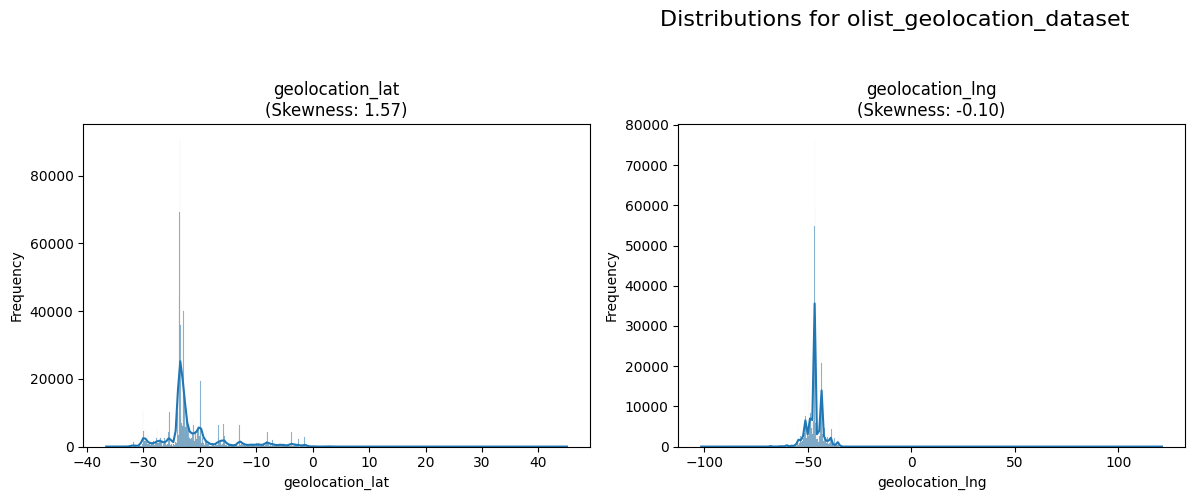


Analyzing DataFrame: olist_order_items_dataset


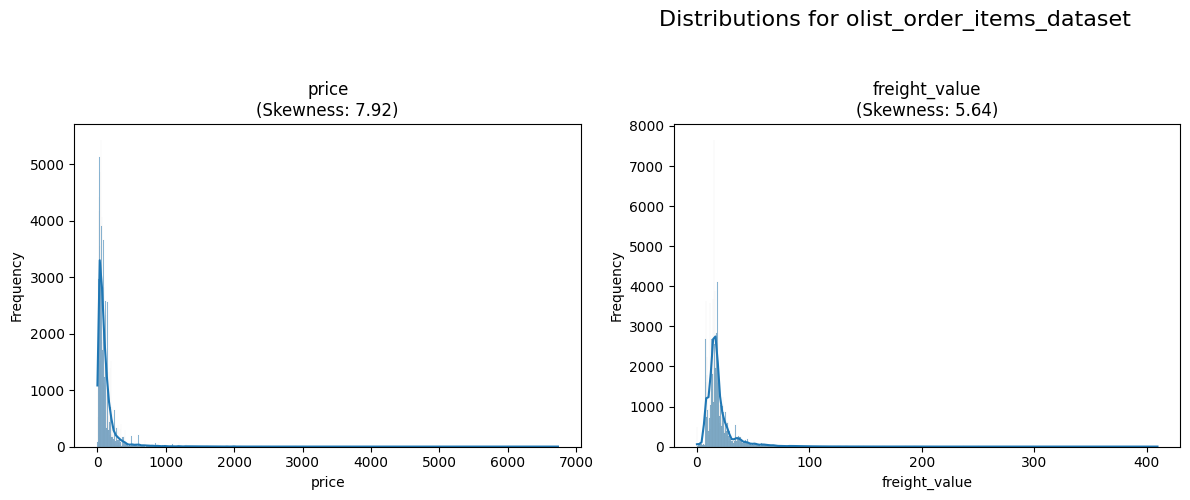


Analyzing DataFrame: olist_order_payments_dataset


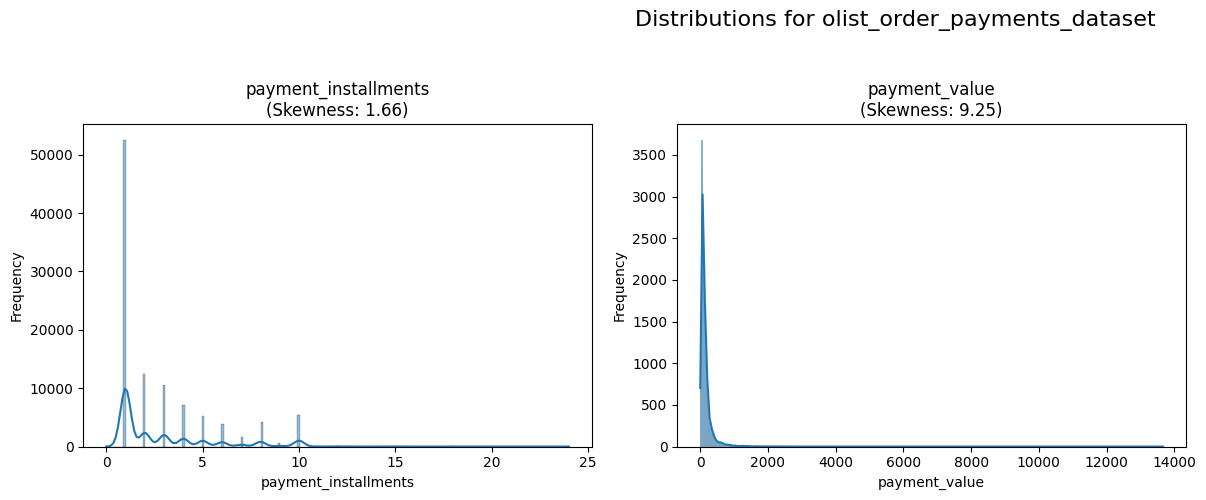


Analyzing DataFrame: olist_order_reviews_dataset


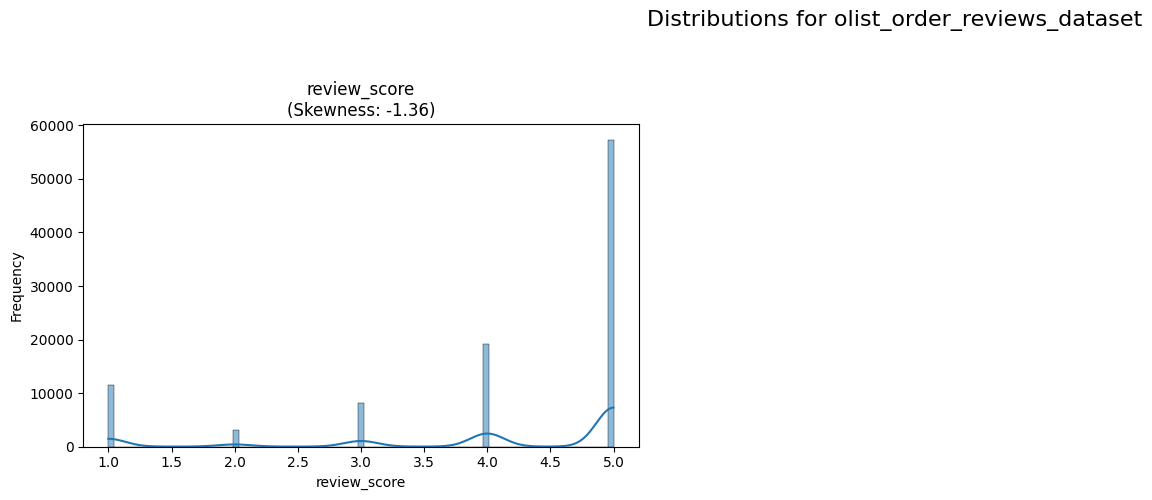


Analyzing DataFrame: olist_orders_dataset
No suitable quantitative columns found in olist_orders_dataset for distribution analysis.

Analyzing DataFrame: olist_products_dataset


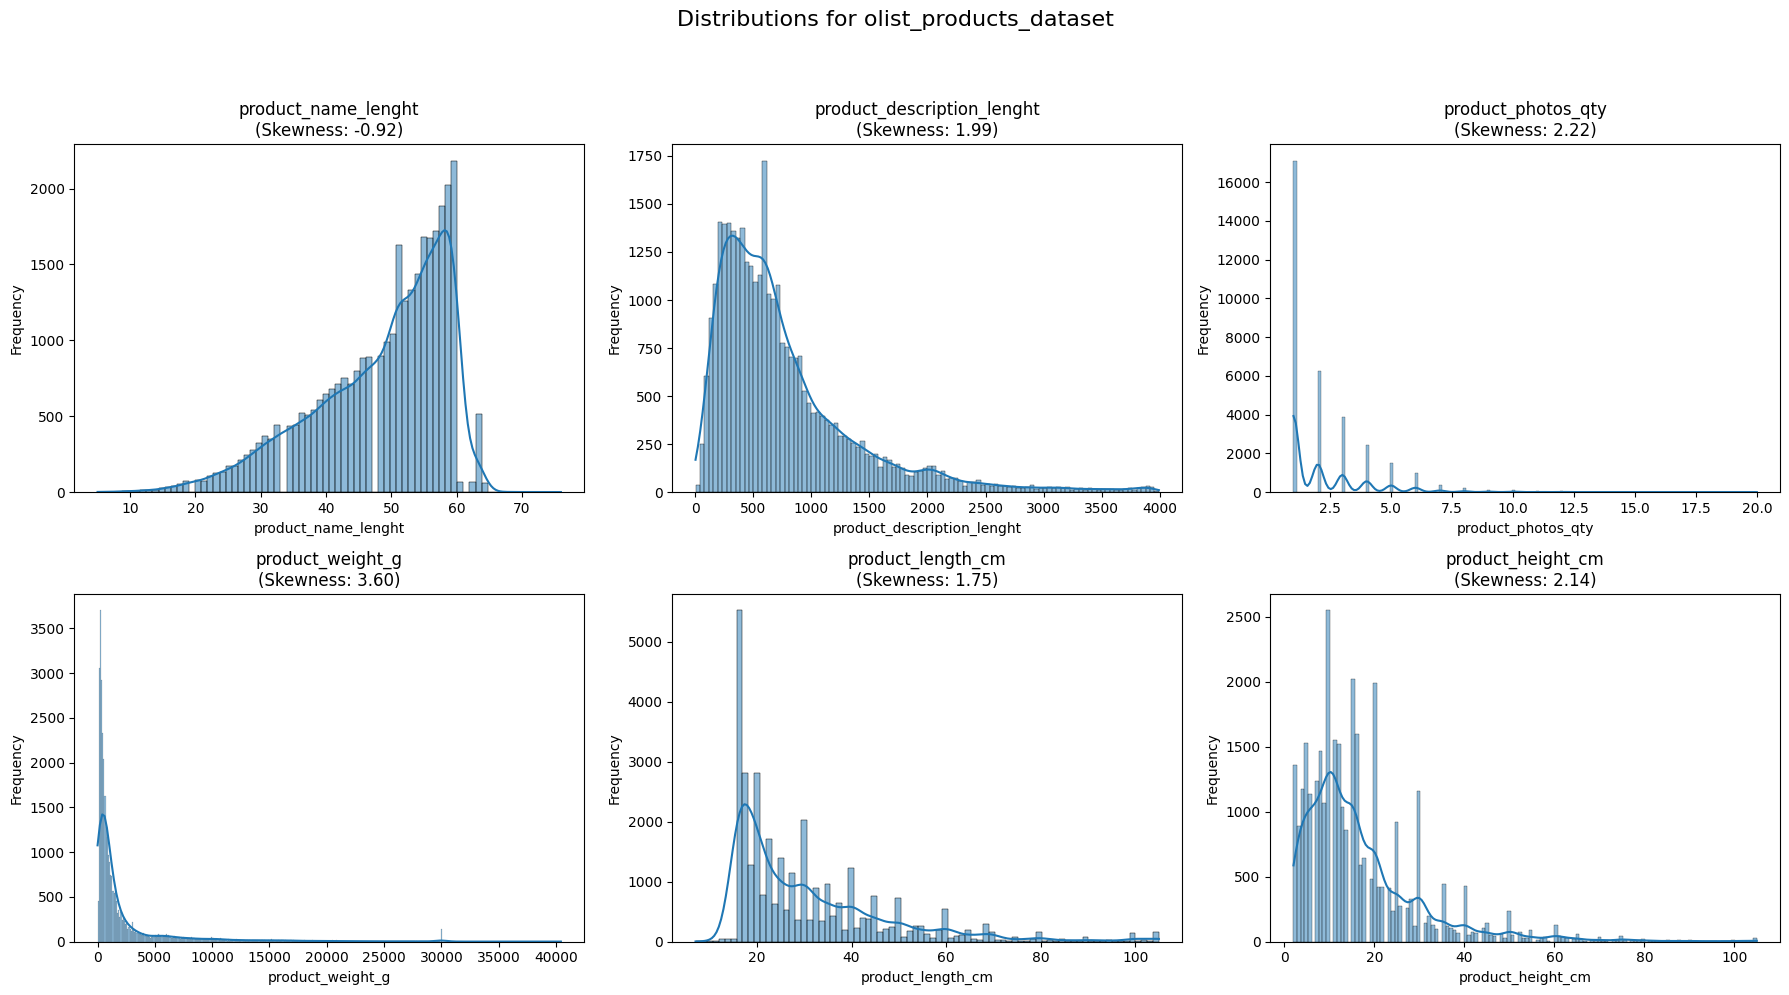


Analyzing DataFrame: olist_sellers_dataset
No suitable quantitative columns found in olist_sellers_dataset for distribution analysis.

Analyzing DataFrame: product_category_name_translation
No suitable quantitative columns found in product_category_name_translation for distribution analysis.

--- All distribution analyses complete. ---


In [10]:
def plot_quantitative_distributions(df_dict, collection_name):
    """
    Plots histograms with KDE and calculates skewness for quantitative columns
    in a dictionary of DataFrames.

    Args:
        df_dict (dict): A dictionary where keys are DataFrame names (str)
                        and values are pandas DataFrames.
        collection_name (str): The name of the collection of DataFrames (e.g., 'Brazilian E-commerce').
    """
    print(f"\n--- Analyzing Distributions for {collection_name} ---")
    for df_name, df in df_dict.items():
        print(f"\nAnalyzing DataFrame: {df_name}")

        # Identify quantitative columns (excluding IDs and zip code prefixes, which are often nominal)
        quantitative_cols = []
        for col in df.select_dtypes(include=np.number).columns:
            # Heuristic to exclude ID-like columns and zip codes, which are numerical but not typically for distribution analysis for mean/median imputation
            if 'id' not in col.lower() and 'zip_code_prefix' not in col.lower() and 'sequential' not in col.lower():
                quantitative_cols.append(col)

        if not quantitative_cols:
            print(f"No suitable quantitative columns found in {df_name} for distribution analysis.")
            continue

        # Determine optimal subplot grid based on number of columns
        n_cols_to_plot = len(quantitative_cols)
        # Ensure at least 1 row if there are columns to plot
        n_rows = max(1, (n_cols_to_plot + 2) // 3) # Roughly 3 columns per row

        plt.figure(figsize=(18, max(5, n_rows * 5))) # Adjust figure size dynamically, minimum height 5
        plt.suptitle(f'Distributions for {df_name}', fontsize=16, y=1.02)

        for i, col in enumerate(quantitative_cols, 1):
            plt.subplot(n_rows, 3, i)
            # Drop NaN values for plotting to avoid errors
            sns.histplot(df[col].dropna(), kde=True)
            skewness = df[col].skew()
            plt.title(f'{col}\n(Skewness: {skewness:.2f})')
            plt.xlabel(col)
            plt.ylabel('Frequency')

        plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
        plt.show()

print("--- Initiating Distribution Analysis Across All Datasets ---")

# Call the function for each dataset collection
plot_quantitative_distributions(dfs, "Brazilian E-commerce Datasets")

print("\n--- All distribution analyses complete. ---")

# 2nd Dataset Check

source: https://www.kaggle.com/datasets/olistbr/marketing-funnel-olist

## Data Load

In [11]:
marketing_funnel_files = [
    "olist_marketing_qualified_leads_dataset.csv",
    "olist_closed_deals_dataset.csv"
]

dfs_marketing_funnel = {}
for file_name in marketing_funnel_files:
    df_name = file_name.replace('.csv', '')
    print(f"Loading {file_name}...")
    dfs_marketing_funnel[df_name] = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "olistbr/marketing-funnel-olist",
        file_name
    )
    print(f"Loaded {df_name} with {len(dfs_marketing_funnel[df_name])} rows.")

Loading olist_marketing_qualified_leads_dataset.csv...


100%|██████████| 687k/687k [00:00<00:00, 1.31MB/s]


Loaded olist_marketing_qualified_leads_dataset with 8000 rows.
Loading olist_closed_deals_dataset.csv...
Using Colab cache for faster access to the 'marketing-funnel-olist' dataset.
Loaded olist_closed_deals_dataset with 842 rows.


In [12]:
print("\nAll loaded marketing funnel DataFrames:", dfs_marketing_funnel.keys())


All loaded marketing funnel DataFrames: dict_keys(['olist_marketing_qualified_leads_dataset', 'olist_closed_deals_dataset'])


## Data Cleaning

In [13]:
#check datatype
for df_name, df in dfs_marketing_funnel.items():
    df.name = df_name
    check_data_types(df, df.columns)


--- Checking Data Types for DataFrame: olist_marketing_qualified_leads_dataset ---
Column 'mql_id': object
Column 'first_contact_date': object
Column 'landing_page_id': object
Column 'origin': object

--- Checking Data Types for DataFrame: olist_closed_deals_dataset ---
Column 'mql_id': object
Column 'seller_id': object
Column 'sdr_id': object
Column 'sr_id': object
Column 'won_date': object
Column 'business_segment': object
Column 'lead_type': object
Column 'lead_behaviour_profile': object
Column 'has_company': object
Column 'has_gtin': object
Column 'average_stock': object
Column 'business_type': object
Column 'declared_product_catalog_size': float64
Column 'declared_monthly_revenue': float64


In [14]:
#check missing value
for df_name, df in dfs_marketing_funnel.items():
    df.name = df_name
    check_missing_values(df, df.columns)


--- Checking Missing Values for DataFrame: olist_marketing_qualified_leads_dataset ---
Column 'mql_id': 0 missing values
Column 'first_contact_date': 0 missing values
Column 'landing_page_id': 0 missing values
Column 'origin': 60 missing values

--- Checking Missing Values for DataFrame: olist_closed_deals_dataset ---
Column 'mql_id': 0 missing values
Column 'seller_id': 0 missing values
Column 'sdr_id': 0 missing values
Column 'sr_id': 0 missing values
Column 'won_date': 0 missing values
Column 'business_segment': 1 missing values
Column 'lead_type': 6 missing values
Column 'lead_behaviour_profile': 177 missing values
Column 'has_company': 779 missing values
Column 'has_gtin': 778 missing values
Column 'average_stock': 776 missing values
Column 'business_type': 10 missing values
Column 'declared_product_catalog_size': 773 missing values
Column 'declared_monthly_revenue': 0 missing values


In [15]:
#check duplicate
for df_name, df in dfs_marketing_funnel.items():
    df.name = df_name
    check_duplicates(df, df.columns)


--- Checking Duplicates for DataFrame: olist_marketing_qualified_leads_dataset ---
Column 'mql_id': 0 duplicate values
Column 'first_contact_date': 7664 duplicate values
Column 'landing_page_id': 7505 duplicate values
Column 'origin': 7989 duplicate values

--- Checking Duplicates for DataFrame: olist_closed_deals_dataset ---
Column 'mql_id': 0 duplicate values
Column 'seller_id': 0 duplicate values
Column 'sdr_id': 810 duplicate values
Column 'sr_id': 820 duplicate values
Column 'won_date': 18 duplicate values
Column 'business_segment': 808 duplicate values
Column 'lead_type': 833 duplicate values
Column 'lead_behaviour_profile': 832 duplicate values
Column 'has_company': 839 duplicate values
Column 'has_gtin': 839 duplicate values
Column 'average_stock': 835 duplicate values
Column 'business_type': 838 duplicate values
Column 'declared_product_catalog_size': 808 duplicate values
Column 'declared_monthly_revenue': 815 duplicate values


## Dataframe Handle

1. fill origin missing value with "unknown" from Marketing Qualified Leads Dataset
2. change every datetime col datatype (powerQuery)
3. fill missing value on Closed Deal Dataset column business_segment, lead_type, lead_behaviour_profile, has_company / has_gtin / average_stock with "Unknown"
4. from Closed Deal Dataset Fill missing declared_product_catalog_size with median.


In [16]:
print("--- Applying data cleaning for Marketing Funnel dataset ---")

# 1. Fill origin missing value with "unknown" from Marketing Qualified Leads Dataset
mql_df = dfs_marketing_funnel['olist_marketing_qualified_leads_dataset']
print(f"Processing: {mql_df.name}")
mql_df['origin'].fillna('unknown', inplace=True)
print("Filled missing 'origin' values with 'unknown'.")

# 2. Fill missing values on Closed Deal Dataset columns with "Unknown"
closed_deals_df = dfs_marketing_funnel['olist_closed_deals_dataset']
print(f"Processing: {closed_deals_df.name}")

string_fill_cols = [
    'business_segment',
    'lead_type',
    'lead_behaviour_profile',
    'has_company',
    'has_gtin',
    'average_stock'
]

for col in string_fill_cols:
    if closed_deals_df[col].isnull().any():
        closed_deals_df[col].fillna('Unknown', inplace=True)
        print(f"Filled missing values in '{col}' with 'Unknown'.")
    else:
        print(f"No missing values found in '{col}'.")

# 3. Fill missing declared_product_catalog_size with median from Closed Deal Dataset
if closed_deals_df['declared_product_catalog_size'].isnull().any():
    median_catalog_size = closed_deals_df['declared_product_catalog_size'].median()
    closed_deals_df['declared_product_catalog_size'].fillna(median_catalog_size, inplace=True)
    print(f"Filled missing values in 'declared_product_catalog_size' with median: {median_catalog_size}.")
else:
    print("No missing values found in 'declared_product_catalog_size'.")

print("--- Data cleaning applied successfully ---")

--- Applying data cleaning for Marketing Funnel dataset ---
Processing: olist_marketing_qualified_leads_dataset
Filled missing 'origin' values with 'unknown'.
Processing: olist_closed_deals_dataset
Filled missing values in 'business_segment' with 'Unknown'.
Filled missing values in 'lead_type' with 'Unknown'.
Filled missing values in 'lead_behaviour_profile' with 'Unknown'.
Filled missing values in 'has_company' with 'Unknown'.
Filled missing values in 'has_gtin' with 'Unknown'.
Filled missing values in 'average_stock' with 'Unknown'.
Filled missing values in 'declared_product_catalog_size' with median: 100.0.
--- Data cleaning applied successfully ---


/tmp/ipykernel_5182/1626831391.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mql_df['origin'].fillna('unknown', inplace=True)
/tmp/ipykernel_5182/1626831391.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

Additionally, I will handle the missing values for `business_type` in `olist_closed_deals_dataset`.

In [17]:
# Fill missing 'business_type' values with 'Unknown' in olist_closed_deals_dataset
closed_deals_df = dfs_marketing_funnel['olist_closed_deals_dataset']
if closed_deals_df['business_type'].isnull().any():
    closed_deals_df['business_type'] = closed_deals_df['business_type'].fillna('Unknown')
    print("Filled missing values in 'business_type' with 'Unknown'.")
else:
    print("No missing values found in 'business_type'.")

Filled missing values in 'business_type' with 'Unknown'.


## Outlier Check


--- Analyzing Distributions for Marketing Funnel Datasets ---

Analyzing DataFrame: olist_marketing_qualified_leads_dataset
No suitable quantitative columns found in olist_marketing_qualified_leads_dataset for distribution analysis.

Analyzing DataFrame: olist_closed_deals_dataset


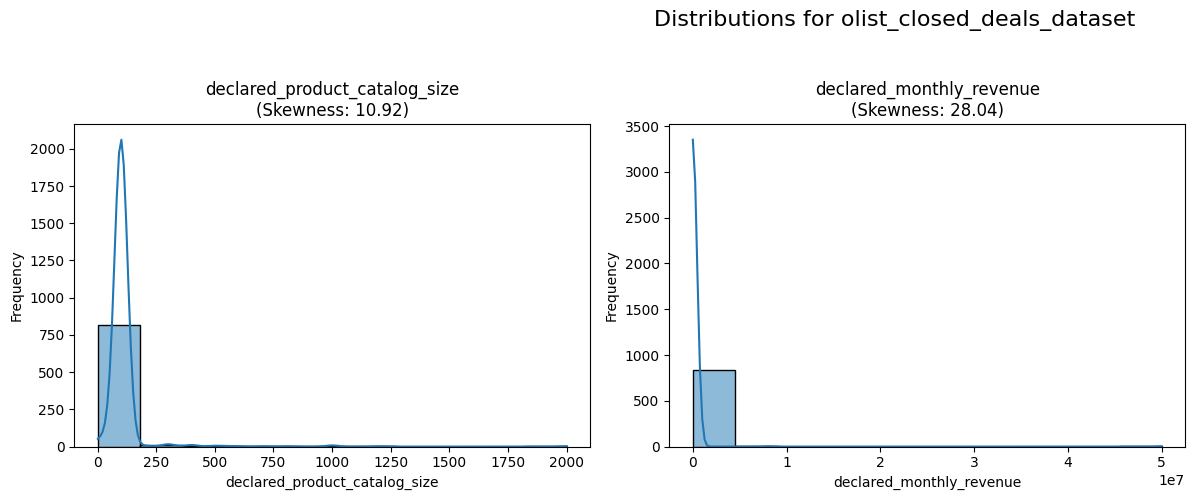

In [18]:
plot_quantitative_distributions(dfs_marketing_funnel, "Marketing Funnel Datasets")

# 3rd Dataset (GDrive)

source: https://docs.google.com/spreadsheets/d/1JND5KOZNwIfsSw-gn-ZQDYB5dPfkHJTvjRtOLQNbaEI/edit?usp=drive_link

## Dataset Load

In [19]:
#3rd dataset
sheet_id = '1JND5KOZNwIfsSw-gn-ZQDYB5dPfkHJTvjRtOLQNbaEI'
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv'

ai_gen_df = pd.read_csv(url)

## Data Cleaning

In [20]:
#check datatype
ai_gen_df.name = 'ai_generated_data' # Assign a name to the DataFrame
check_data_types(ai_gen_df, ai_gen_df.columns)


--- Checking Data Types for DataFrame: ai_generated_data ---
Column 'customer_id': object
Column 'customer_loyalty_tier': object
Column 'estimated_customer_lifetime_value': float64
Column 'repeat_purchase_probability': int64
Column 'churn_risk_score': int64
Column 'digital_engagement_score': float64
Column 'preferred_shopping_channel': object
Column 'discount_sensitivity_score': float64
Column 'customer_satisfaction_index': float64
Column 'average_monthly_spending': float64
Column 'return_probability': float64
Column 'promotion_response_rate': float64
Column 'customer_segment': object
Column 'membership_duration_months': int64
Column 'preferred_product_category': object
Column 'payment_preference': object


In [21]:
#check missing value
check_missing_values(ai_gen_df, ai_gen_df.columns)


--- Checking Missing Values for DataFrame: ai_generated_data ---
Column 'customer_id': 0 missing values
Column 'customer_loyalty_tier': 0 missing values
Column 'estimated_customer_lifetime_value': 3935 missing values
Column 'repeat_purchase_probability': 0 missing values
Column 'churn_risk_score': 0 missing values
Column 'digital_engagement_score': 5958 missing values
Column 'preferred_shopping_channel': 0 missing values
Column 'discount_sensitivity_score': 5018 missing values
Column 'customer_satisfaction_index': 5087 missing values
Column 'average_monthly_spending': 0 missing values
Column 'return_probability': 7063 missing values
Column 'promotion_response_rate': 5982 missing values
Column 'customer_segment': 0 missing values
Column 'membership_duration_months': 0 missing values
Column 'preferred_product_category': 3994 missing values
Column 'payment_preference': 3042 missing values


In [22]:
#check duplicate
check_duplicates(ai_gen_df, ai_gen_df.columns)


--- Checking Duplicates for DataFrame: ai_generated_data ---
Column 'customer_id': 0 duplicate values
Column 'customer_loyalty_tier': 99996 duplicate values
Column 'estimated_customer_lifetime_value': 22203 duplicate values
Column 'repeat_purchase_probability': 99899 duplicate values
Column 'churn_risk_score': 99899 duplicate values
Column 'digital_engagement_score': 99899 duplicate values
Column 'preferred_shopping_channel': 99996 duplicate values
Column 'discount_sensitivity_score': 99899 duplicate values
Column 'customer_satisfaction_index': 99908 duplicate values
Column 'average_monthly_spending': 44720 duplicate values
Column 'return_probability': 99924 duplicate values
Column 'promotion_response_rate': 99902 duplicate values
Column 'customer_segment': 99995 duplicate values
Column 'membership_duration_months': 99903 duplicate values
Column 'preferred_product_category': 99991 duplicate values
Column 'payment_preference': 99994 duplicate values


## Data handling

1. fill in estimated_customer_lifetime_value, digital_engagement_score, discount_sensitivity_score, customer_satisfaction_index , return_probability,  promotion_response_rate column with median
2. fill in preferred_product_category, payment_preference with "Unknown"


In [23]:
print("--- Applying data cleaning for AI Generated DataFrame ---")

# 1. Fill in numerical columns with median
median_fill_cols = [
    'estimated_customer_lifetime_value',
    'digital_engagement_score',
    'discount_sensitivity_score',
    'customer_satisfaction_index',
    'return_probability',
    'promotion_response_rate'
]

for col in median_fill_cols:
    if ai_gen_df[col].isnull().any():
        median_value = ai_gen_df[col].median()
        ai_gen_df[col].fillna(median_value, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_value}.")
    else:
        print(f"No missing values found in '{col}'.")

# 2. Fill in categorical columns with "Unknown"
unknown_fill_cols = [
    'preferred_product_category',
    'payment_preference'
]

for col in unknown_fill_cols:
    if ai_gen_df[col].isnull().any():
        ai_gen_df[col].fillna('Unknown', inplace=True)
        print(f"Filled missing values in '{col}' with 'Unknown'.")
    else:
        print(f"No missing values found in '{col}'.")

print("--- Data cleaning applied successfully ---")

--- Applying data cleaning for AI Generated DataFrame ---
Filled missing values in 'estimated_customer_lifetime_value' with median: 1803.14.
Filled missing values in 'digital_engagement_score' with median: 49.0.
Filled missing values in 'discount_sensitivity_score' with median: 54.0.
Filled missing values in 'customer_satisfaction_index' with median: 6.5.
Filled missing values in 'return_probability' with median: 26.0.
Filled missing values in 'promotion_response_rate' with median: 47.0.
Filled missing values in 'preferred_product_category' with 'Unknown'.
Filled missing values in 'payment_preference' with 'Unknown'.
--- Data cleaning applied successfully ---


/tmp/ipykernel_5182/1954780912.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ai_gen_df[col].fillna(median_value, inplace=True)
/tmp/ipykernel_5182/1954780912.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

## Outlier Check


--- Analyzing Distributions for AI Generated Data DataFrame ---

Analyzing DataFrame: ai_gen_df


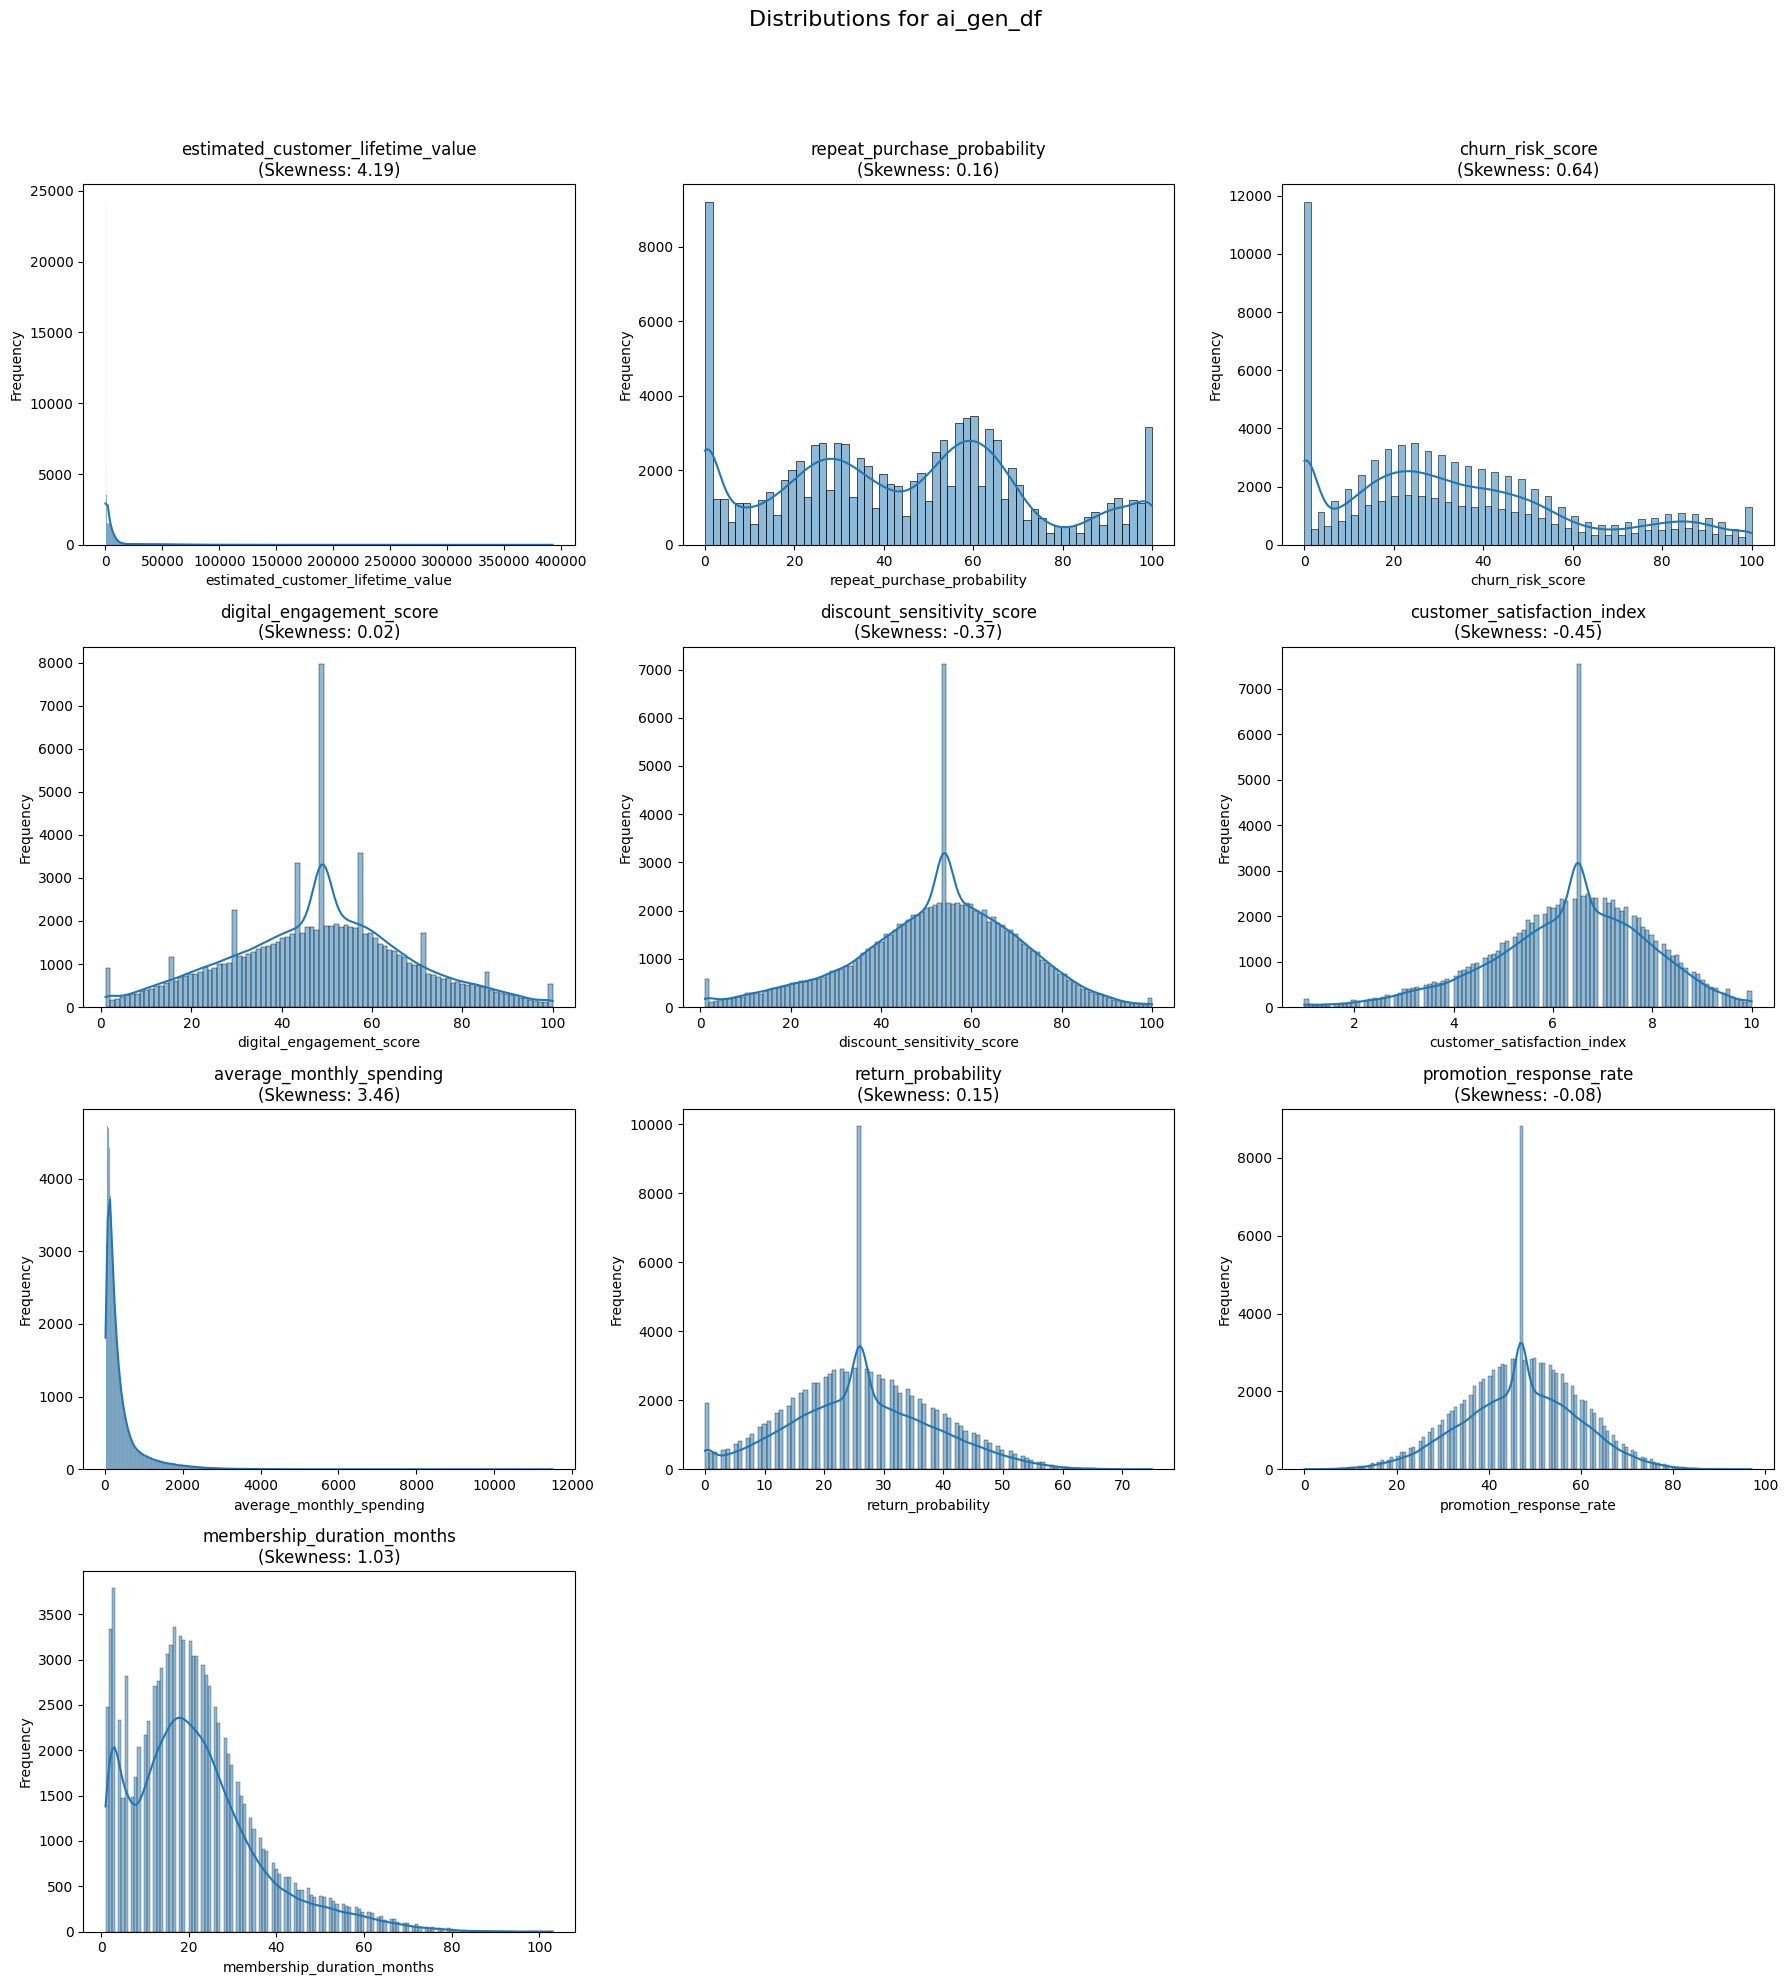

In [24]:
plot_quantitative_distributions({'ai_gen_df': ai_gen_df}, "AI Generated Data DataFrame")

In [25]:
print("\n--- Row Counts for Brazilian E-commerce Datasets ---")
for df_name, df in dfs.items():
    print(f"DataFrame '{df_name}': {len(df)} rows")

print("\n--- Row Counts for Marketing Funnel Datasets ---")
for df_name, df in dfs_marketing_funnel.items():
    print(f"DataFrame '{df_name}': {len(df)} rows")

print("\n--- Row Count for AI Generated Data DataFrame ---")
print(f"DataFrame 'ai_gen_df': {len(ai_gen_df)} rows")


--- Row Counts for Brazilian E-commerce Datasets ---
DataFrame 'olist_customers_dataset': 99441 rows
DataFrame 'olist_geolocation_dataset': 1000163 rows
DataFrame 'olist_order_items_dataset': 112650 rows
DataFrame 'olist_order_payments_dataset': 103886 rows
DataFrame 'olist_order_reviews_dataset': 99224 rows
DataFrame 'olist_orders_dataset': 99441 rows
DataFrame 'olist_products_dataset': 32951 rows
DataFrame 'olist_sellers_dataset': 3095 rows
DataFrame 'product_category_name_translation': 71 rows

--- Row Counts for Marketing Funnel Datasets ---
DataFrame 'olist_marketing_qualified_leads_dataset': 8000 rows
DataFrame 'olist_closed_deals_dataset': 842 rows

--- Row Count for AI Generated Data DataFrame ---
DataFrame 'ai_gen_df': 100000 rows


# Data Cleaning & EDA

## Categorical Feature

--- Initiating Categorical Feature Analysis Across All Datasets ---

--- Analyzing Categorical Columns for Brazilian E-commerce Datasets ---

Analyzing DataFrame: olist_customers_dataset

Column: 'customer_id'
Value Counts:
customer_id
274fa6071e5e17fe303b9748641082c8    1
e5ed7280cd1a3ac2ba29fd6650d8867c    1
c6ece8a5137f3c9c3a3a12302a19a2ac    1
821a7275a08f32975caceff2e08ea262    1
5eef6cce1f34954c9e7004332388ccc7    1
                                   ..
879864dab9bc3047522c92c82e1212b8    1
4f2d8ab171c80ec8364f7c12e35b23ad    1
b2b6027bc5c5109e529d4dc6358b12c3    1
4e7b3e00288586ebd08712fdd0374a03    1
18955e83d337fd6b2def6b18a428ac77    1
Name: count, Length: 99441, dtype: int64
Skipping plot for 'customer_id' due to too many unique categories (99441).

Column: 'customer_unique_id'
Value Counts:
customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9

/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


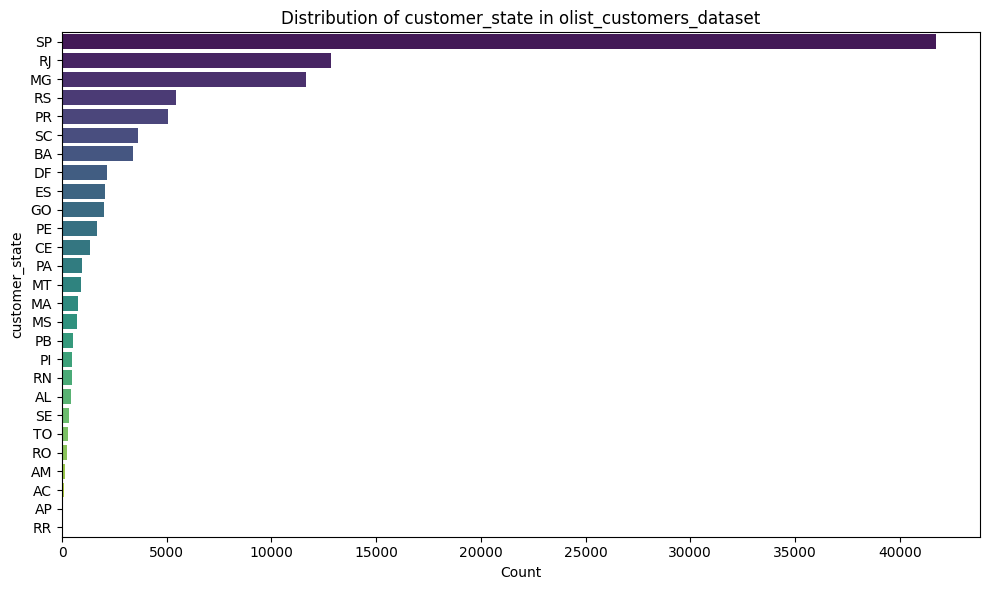


Analyzing DataFrame: olist_geolocation_dataset

Column: 'geolocation_city'
Value Counts:
geolocation_city
sao paulo         135800
rio de janeiro     62151
belo horizonte     27805
são paulo          24918
curitiba           16593
                   ...  
tres irmaos            1
morro chato            1
valao do barro         1
jordanésia             1
são valentim           1
Name: count, Length: 8011, dtype: int64
Skipping plot for 'geolocation_city' due to too many unique categories (8011).

Column: 'geolocation_state'
Value Counts:
geolocation_state
SP    404268
MG    126336
RJ    121169
RS     61851
PR     57859
SC     38328
BA     36045
GO     20139
ES     16748
PE     16432
DF     12986
MT     12031
CE     11674
PA     10853
MS     10431
MA      7853
PB      5538
RN      5041
PI      4549
AL      4183
TO      3576
SE      3563
RO      3478
AM      2432
AC      1301
AP       853
RR       646
Name: count, dtype: int64


/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


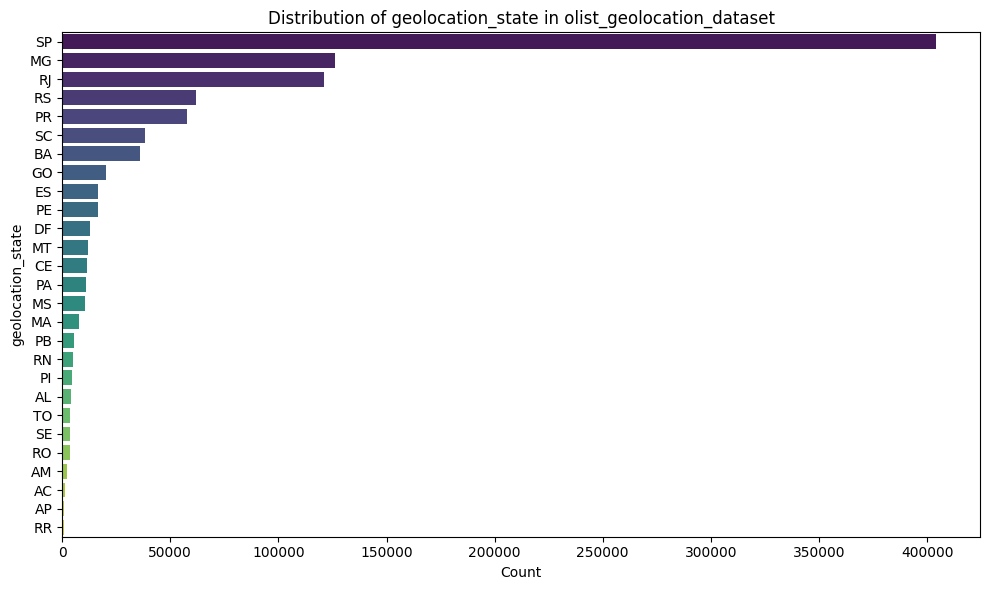


Analyzing DataFrame: olist_order_items_dataset

Column: 'order_id'
Value Counts:
order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
                                    ..
5a082b558a3798d3e36d93bfa8ca1eae     1
5a07264682e0b8fbb3f166edbbffc6e8     1
5a071192a28951b76774e5a760c8c9b7     1
5a06fc966a12b41bf401b344464fd4b1     1
5a0e5ad33542c79b10be87a344ee0086     1
Name: count, Length: 98666, dtype: int64
Skipping plot for 'order_id' due to too many unique categories (98666).

Column: 'product_id'
Value Counts:
product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
                                   ... 
038c0dd7c1e48a1588f8919a0c305727      1
aa20709d44e96059764f1b0386d3bcfa      1


/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


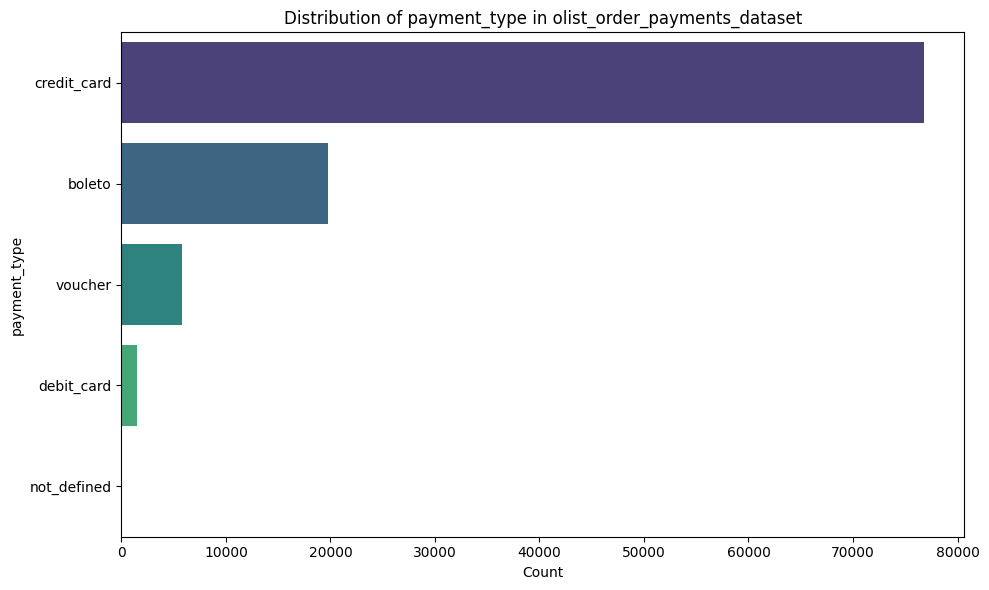


Analyzing DataFrame: olist_order_reviews_dataset

Column: 'review_id'
Value Counts:
review_id
4548534449b1f572e357211b90724f1b    3
44e9f871226d8a130de3fc39dfbdf0c5    3
2d6ac45f859465b5c185274a1c929637    3
ddc52555ca27b0fe67d5255147682d2d    3
08528f70f579f0c830189efc523d2182    3
                                   ..
ca475b77fcc618551ef9d516c3f61b88    1
95a8d0270bdd512d3c2e03a885f21d27    1
93016126c7a3060a49c6975fab7a9c16    1
0a77ca646b0b9b7a209e97589adf9d88    1
11d8992bd767ff693cfa2fb3f930f65a    1
Name: count, Length: 98410, dtype: int64
Skipping plot for 'review_id' due to too many unique categories (98410).

Column: 'order_id'
Value Counts:
order_id
03c939fd7fd3b38f8485a0f95798f1f6    3
8e17072ec97ce29f0e1f111e598b0c85    3
c88b1d1b157a9999ce368f218a407141    3
df56136b8031ecd28e200bb18e6ddb2e    3
843be4a0dcdb9716de7652d53af4acab    2
                                   ..
bad0467c52f23cdc71e9fa139d4a8afd    1
6acf2b0f288195a72858fa65ff2c43c7    1
4634ad13b4414c83524f5efb0e

/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


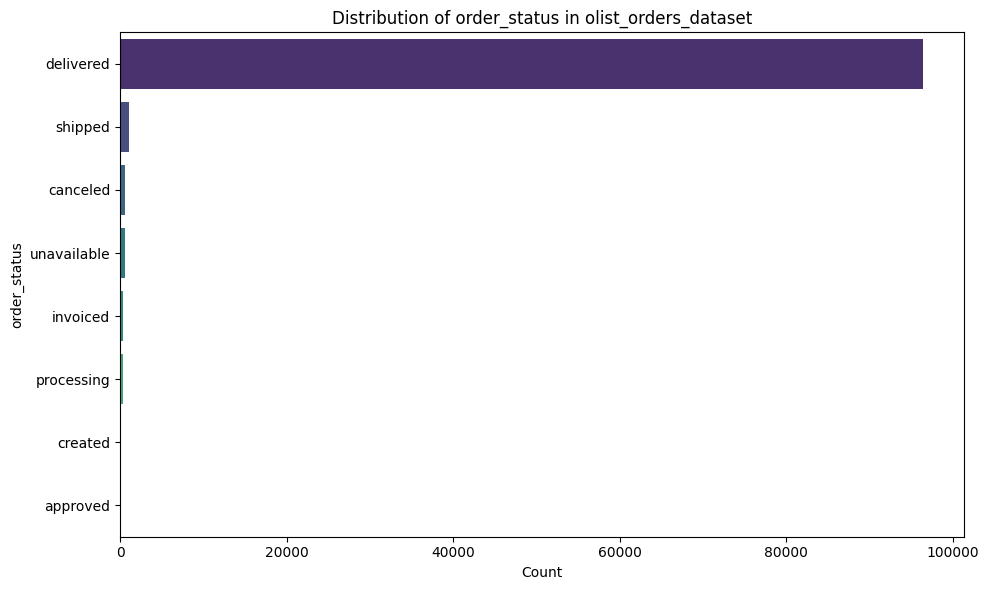


Column: 'order_purchase_timestamp'
Value Counts:
order_purchase_timestamp
2018-08-02 12:06:07    3
2018-04-11 10:48:14    3
2018-08-02 12:05:26    3
2018-02-19 15:37:47    3
2017-11-20 11:46:30    3
                      ..
2018-03-17 23:46:08    1
2017-07-12 13:42:13    1
2018-03-31 14:24:53    1
2018-01-09 12:21:52    1
2018-01-02 14:04:54    1
Name: count, Length: 98875, dtype: int64
Skipping plot for 'order_purchase_timestamp' due to too many unique categories (98875).

Column: 'order_approved_at'
Value Counts:
order_approved_at
NaN                    160
2018-02-27 04:31:10      9
2017-11-07 07:30:29      7
2018-02-06 05:31:52      7
2018-02-27 04:31:01      7
                      ... 
2018-04-16 15:15:25      1
2017-03-13 02:22:34      1
2018-01-25 15:09:37      1
2017-06-02 20:05:13      1
2018-08-16 11:50:15      1
Name: count, Length: 90734, dtype: int64
Skipping plot for 'order_approved_at' due to too many unique categories (90734).

Column: 'order_delivered_carrier_date'
V

/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


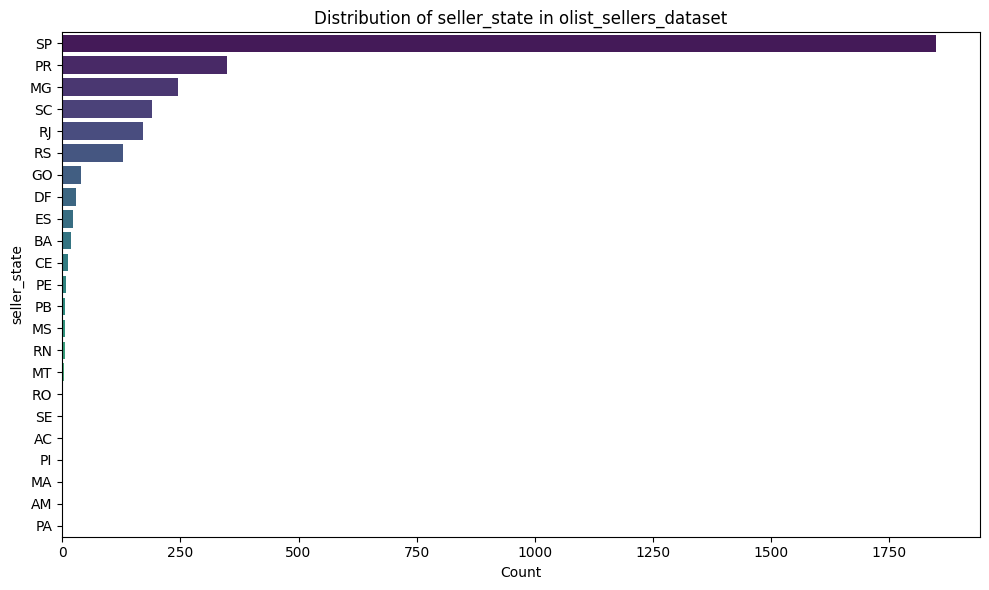


Analyzing DataFrame: product_category_name_translation

Column: 'product_category_name'
Value Counts:
product_category_name
beleza_saude                     1
informatica_acessorios           1
automotivo                       1
cama_mesa_banho                  1
moveis_decoracao                 1
                                ..
flores                           1
artes_e_artesanato               1
fraldas_higiene                  1
fashion_roupa_infanto_juvenil    1
seguros_e_servicos               1
Name: count, Length: 71, dtype: int64
Skipping plot for 'product_category_name' due to too many unique categories (71).

Column: 'product_category_name_english'
Value Counts:
product_category_name_english
health_beauty                1
computers_accessories        1
auto                         1
bed_bath_table               1
furniture_decor              1
                            ..
flowers                      1
arts_and_craftmanship        1
diapers_and_hygiene          1
fashio

/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


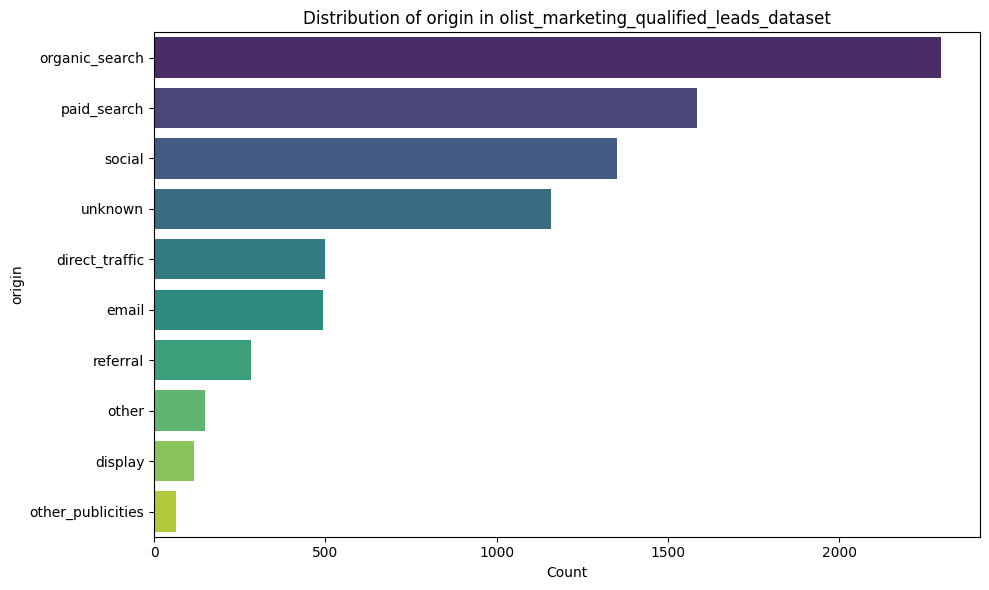


Analyzing DataFrame: olist_closed_deals_dataset

Column: 'mql_id'
Value Counts:
mql_id
8a6492305a5fbcdcdd1a7f5a90764c07    1
5420aad7fec3549a85876ba1c529bd84    1
a555fb36b9368110ede0f043dfc3b9a0    1
327174d3648a2d047e8940d7d15204ca    1
f5fee8f7da74f4887f5bcae2bafb6dd6    1
                                   ..
ab11f58a6bf7036a656364b0ba68fb74    1
67455a0673f5cf26deae5b270c003e83    1
c556184b3fe2087834850b68fa435cee    1
408a9c4a79800232ac656249af3162eb    1
4e4e70d504b4c0006c8287dedc99d0fc    1
Name: count, Length: 842, dtype: int64
Skipping plot for 'mql_id' due to too many unique categories (842).

Column: 'seller_id'
Value Counts:
seller_id
1bba9c94eb5c4e82fba9f7286fe81025    1
2c43fb513632d29b3b58df74816f1b06    1
bbb7d7893a450660432ea6652310ebb7    1
612170e34b97004b3ba37eae81836b4c    1
21e1781e36faf92725dde4730a88ca0f    1
                                   ..
9e7c5f4d7770eab65738cca38f9efccf    1
e7012030d0fdd1d3ca504f6de7909c35    1
2d2322d842118867781fc737e96d59a1    1


/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


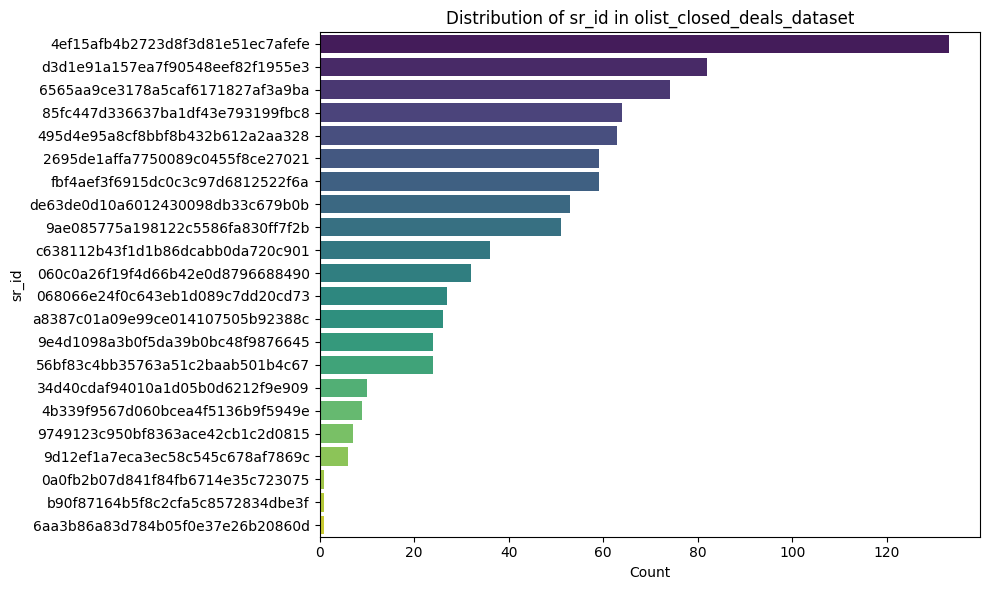


Column: 'won_date'
Value Counts:
won_date
2018-05-04 03:00:00    6
2018-04-24 03:00:00    4
2018-03-27 03:00:00    3
2018-04-13 03:00:00    3
2018-04-30 03:00:00    2
                      ..
2018-04-24 14:19:33    1
2018-05-11 19:21:23    1
2018-04-27 13:27:25    1
2018-04-25 21:44:40    1
2018-04-18 20:19:00    1
Name: count, Length: 824, dtype: int64
Skipping plot for 'won_date' due to too many unique categories (824).

Column: 'business_segment'
Value Counts:
business_segment
home_decor                         105
health_beauty                       93
car_accessories                     77
household_utilities                 71
construction_tools_house_garden     69
audio_video_electronics             64
computers                           34
pet                                 30
food_supplement                     28
food_drink                          26
sports_leisure                      25
bed_bath_table                      22
bags_backpacks                      22
toys   

/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


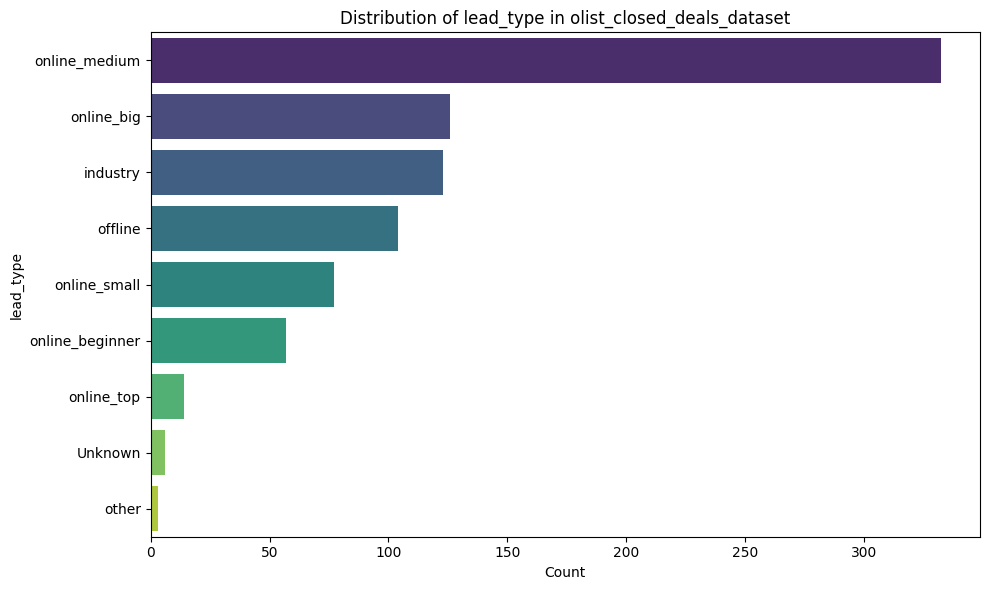


Column: 'lead_behaviour_profile'
Value Counts:
lead_behaviour_profile
cat            407
Unknown        177
eagle          123
wolf            95
shark           24
cat, wolf        8
eagle, wolf      3
eagle, cat       3
shark, cat       1
shark, wolf      1
Name: count, dtype: int64


/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


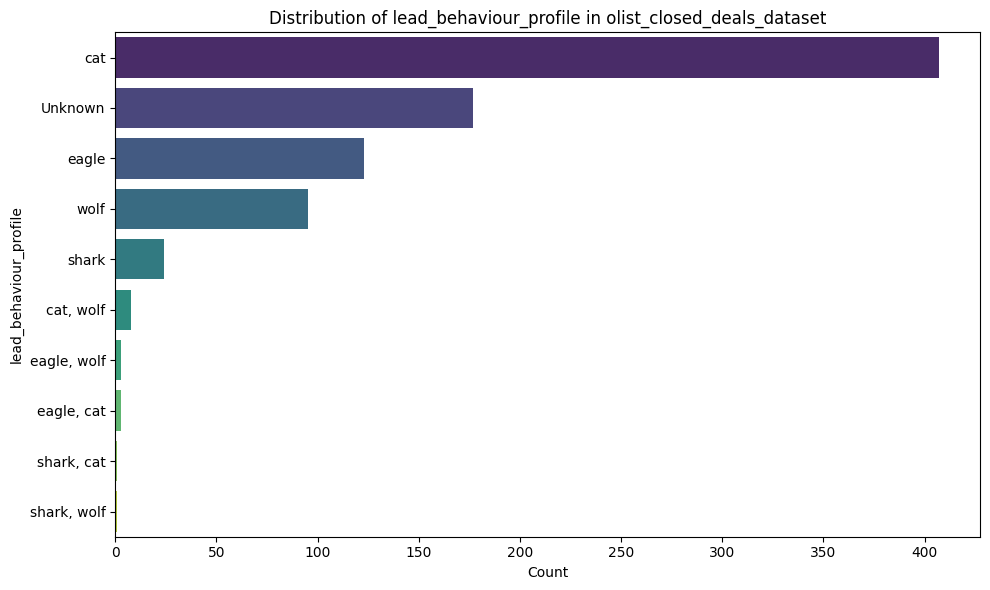


Column: 'has_company'
Value Counts:
has_company
Unknown    779
True        58
False        5
Name: count, dtype: int64


/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


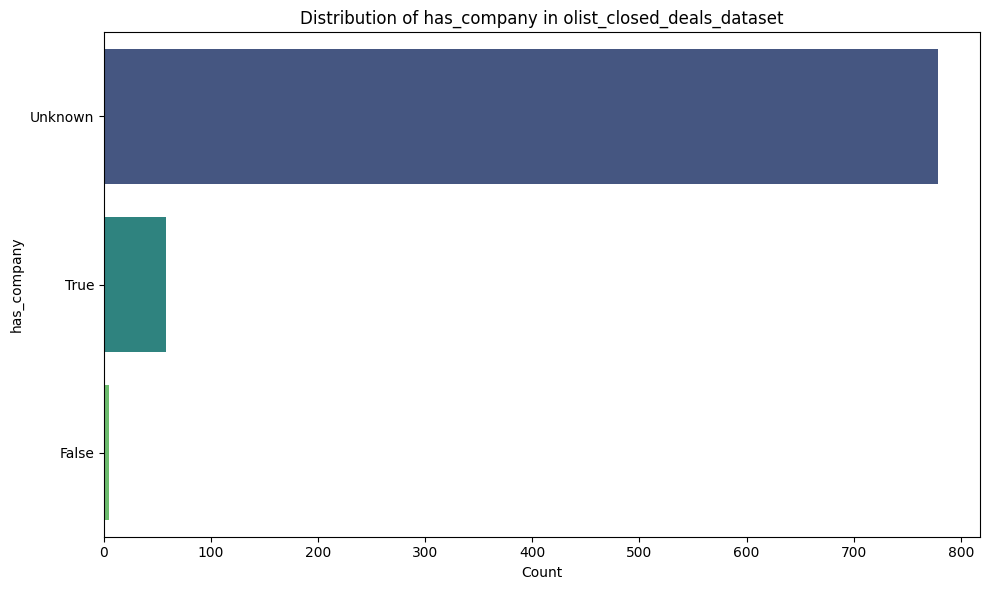


Column: 'has_gtin'
Value Counts:
has_gtin
Unknown    778
True        54
False       10
Name: count, dtype: int64


/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


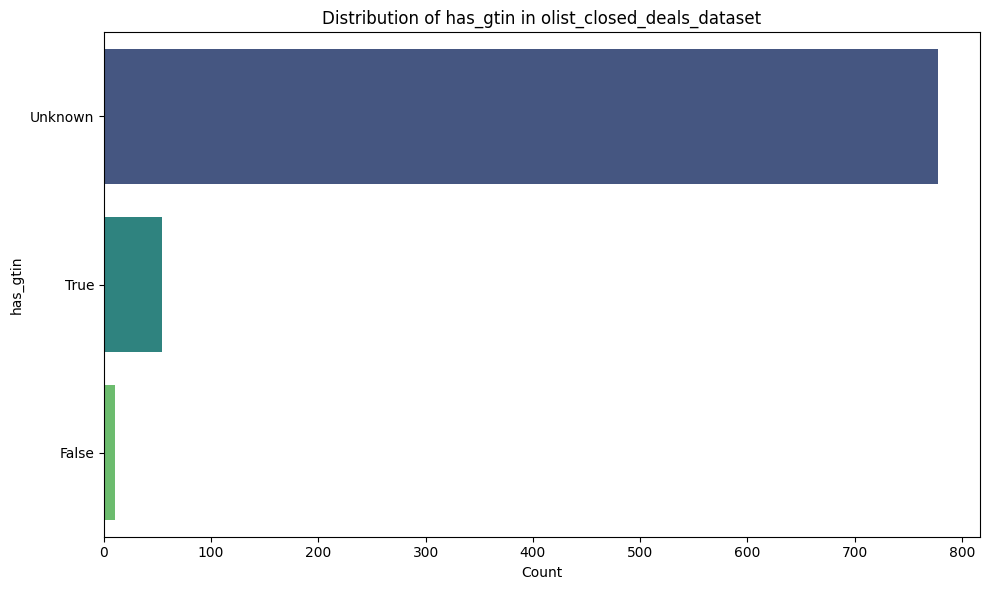


Column: 'average_stock'
Value Counts:
average_stock
Unknown    776
5-20        22
50-200      15
1-5         10
20-50        8
200+         7
unknown      4
Name: count, dtype: int64


/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


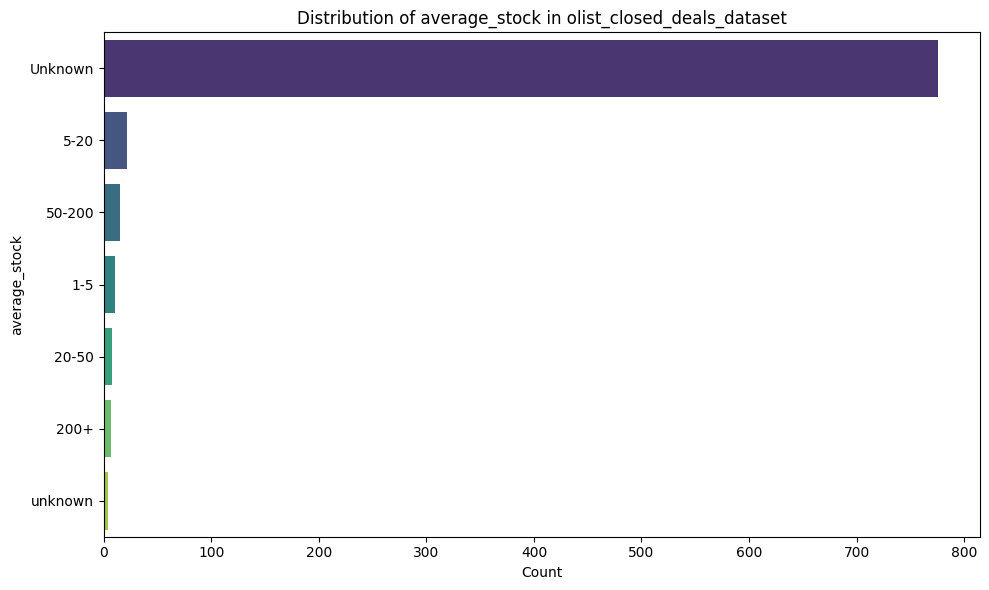


Column: 'business_type'
Value Counts:
business_type
reseller        587
manufacturer    242
Unknown          10
other             3
Name: count, dtype: int64


/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


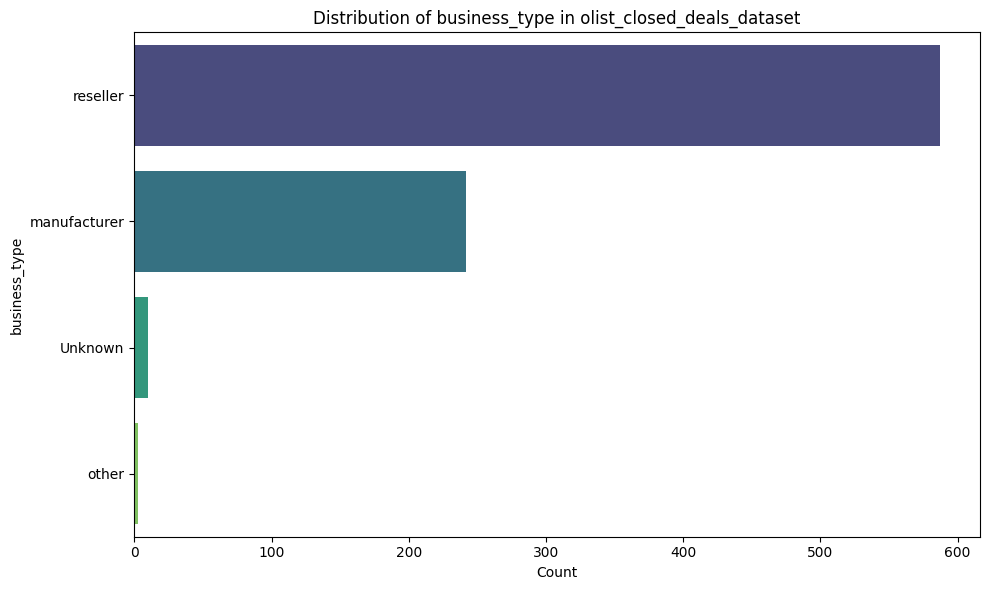


--- Analyzing Categorical Columns for AI Generated Data DataFrame ---

Analyzing DataFrame: ai_gen_df

Column: 'customer_id'
Value Counts:
customer_id
77c8b425bbdd9a2dc2631f099d1e13e7    1
a286914f694052cdc429ab4bd103db2b    1
e15b03225cca124b3322506e80a91cf3    1
20bc4b5f9074a1f098b1306f34a862d5    1
b1657c027b4558795ddceae123ef1a2e    1
                                   ..
71b7f1a429c56bb47a4ebc5dcf762053    1
f7e90b6cdb73b72f7a79e457d522b659    1
3fbe8eabbf62ece411213e0f139a6229    1
2620423ea9fa7e592376a5f7cb8963ff    1
1164e8601ea0f8d70108383c7261dcf4    1
Name: count, Length: 100000, dtype: int64
Skipping plot for 'customer_id' due to too many unique categories (100000).

Column: 'customer_loyalty_tier'
Value Counts:
customer_loyalty_tier
Bronze      39935
Silver      34882
Gold        18669
Platinum     6514
Name: count, dtype: int64


/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


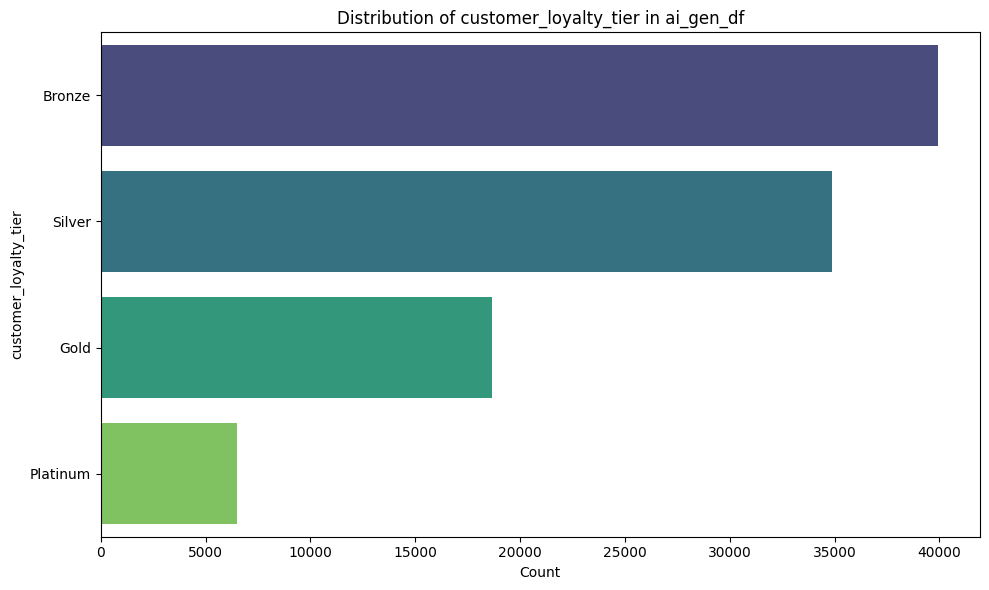


Column: 'preferred_shopping_channel'
Value Counts:
preferred_shopping_channel
Marketplace        32124
Mobile App         31217
Website            25997
Social Commerce    10662
Name: count, dtype: int64


/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


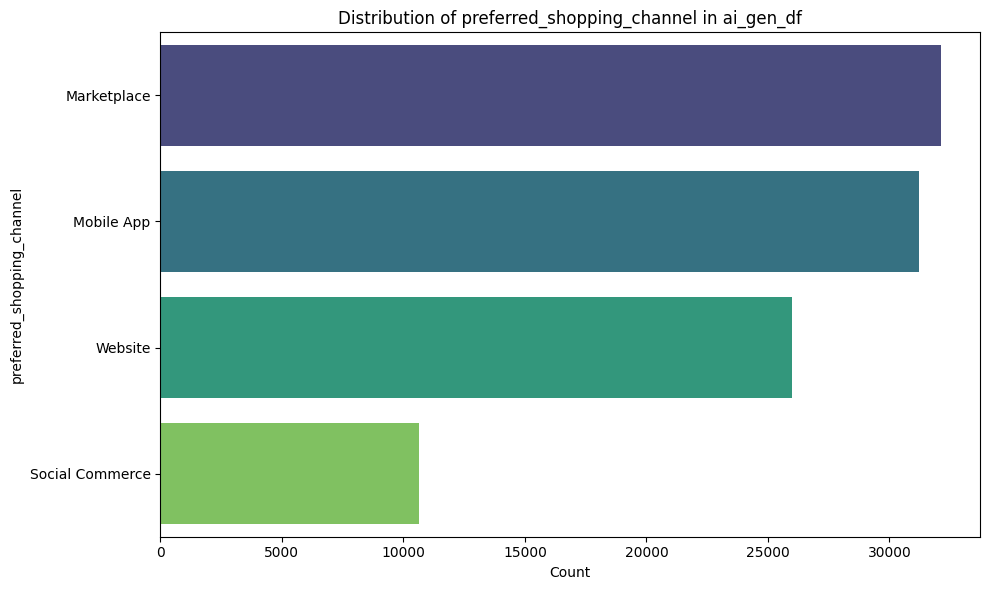


Column: 'customer_segment'
Value Counts:
customer_segment
Regular         38076
Occasional      25064
At Risk         14951
High Value      11863
New Customer    10046
Name: count, dtype: int64


/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


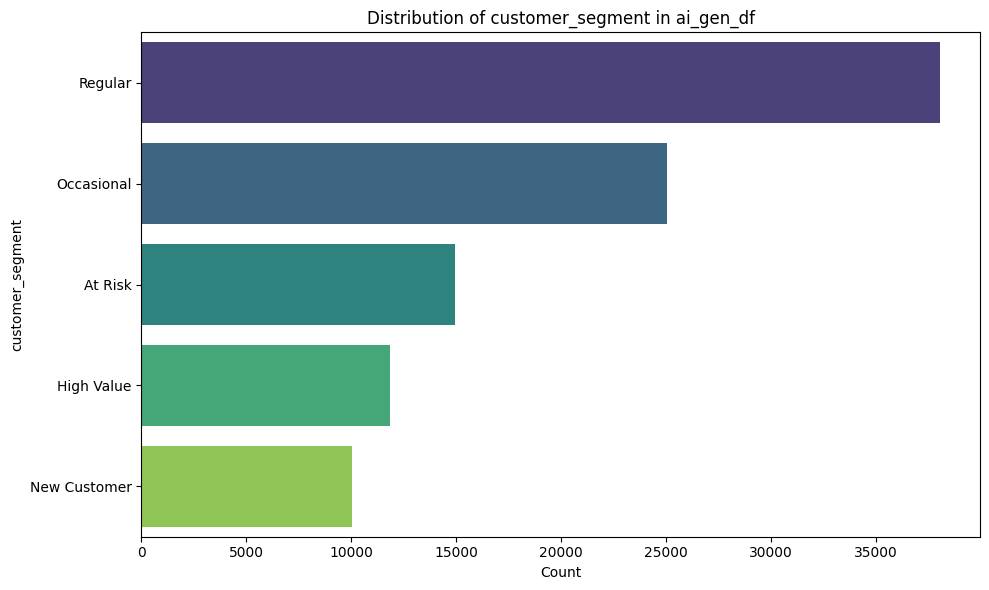


Column: 'preferred_product_category'
Value Counts:
preferred_product_category
fashion        20261
electronics    16170
beauty         14397
home           13986
sports          9740
toys            7904
health          7760
groceries       5788
Unknown         3994
Name: count, dtype: int64


/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


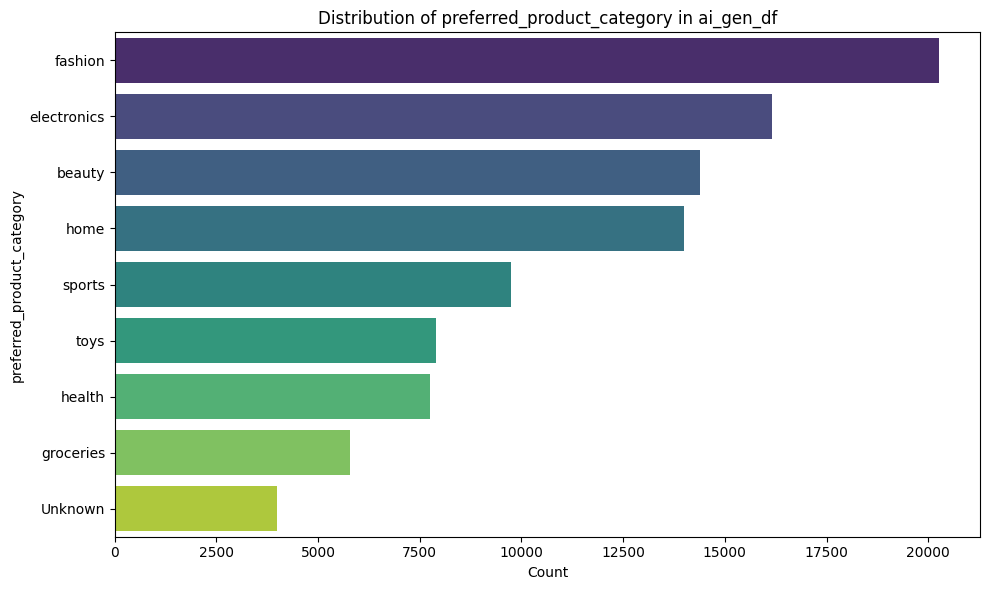


Column: 'payment_preference'
Value Counts:
payment_preference
Credit Card            32416
Digital Wallet         23472
Debit Card             19250
Installment Payment    13868
Bank Transfer           7952
Unknown                 3042
Name: count, dtype: int64


/tmp/ipykernel_5182/2734259693.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')


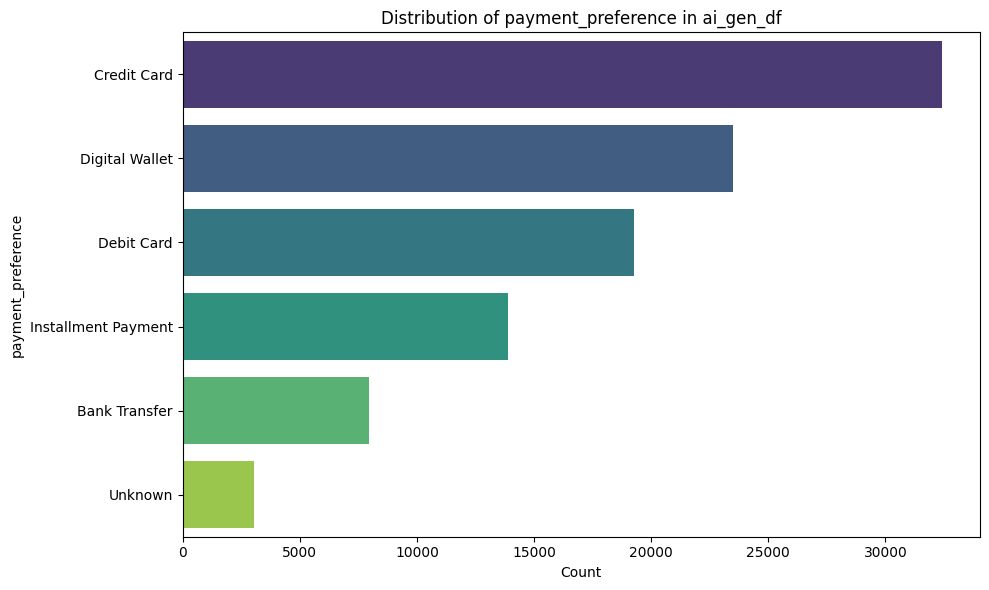


--- All categorical feature analyses complete. ---


In [26]:
def analyze_categorical_columns(df_dict, collection_name, max_categories_to_plot=30):
    """
    Analyzes and visualizes categorical columns in a dictionary of DataFrames.

    Args:
        df_dict (dict): A dictionary where keys are DataFrame names (str)
                        and values are pandas DataFrames.
        collection_name (str): The name of the collection of DataFrames (e.g., 'Brazilian E-commerce').
        max_categories_to_plot (int): Maximum number of unique categories for which to generate a bar plot.
    """
    print(f"\n--- Analyzing Categorical Columns for {collection_name} ---")
    for df_name, df in df_dict.items():
        print(f"\nAnalyzing DataFrame: {df_name}")

        categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

        if not categorical_cols:
            print(f"No categorical columns found in {df_name}.")
            continue

        for col in categorical_cols:
            print(f"\nColumn: '{col}'")
            value_counts = df[col].value_counts(dropna=False) # Include NaN counts
            print("Value Counts:")
            print(value_counts)

            # Plot if the number of unique categories is manageable
            if len(value_counts) <= max_categories_to_plot and len(value_counts) > 1:
                plt.figure(figsize=(10, 6))
                sns.countplot(data=df, y=col, order=value_counts.index, palette='viridis')
                plt.title(f'Distribution of {col} in {df_name}')
                plt.xlabel('Count')
                plt.ylabel(col)
                plt.tight_layout()
                plt.show()
            elif len(value_counts) > max_categories_to_plot:
                print(f"Skipping plot for '{col}' due to too many unique categories ({len(value_counts)}).")
            else:
                print(f"Skipping plot for '{col}' as it has only one unique value.")

print("--- Initiating Categorical Feature Analysis Across All Datasets ---")

# Call the function for each dataset collection
analyze_categorical_columns(dfs, "Brazilian E-commerce Datasets")
analyze_categorical_columns(dfs_marketing_funnel, "Marketing Funnel Datasets")
analyze_categorical_columns({'ai_gen_df': ai_gen_df}, "AI Generated Data DataFrame")

print("\n--- All categorical feature analyses complete. ---")

In [27]:
#clean review message
positive_words = [
    'bom', 'muito bom', 'otimo',
    'excelente', 'recomendo',
    'perfeito', 'gostei'
]

negative_words = [
    'ruim', 'atraso', 'péssimo',
    'problema', 'defeito',
    'demora', 'cancelado'
]

def classify_review(text):
    text = str(text).lower()

    if text == 'no review':
        return 'No Review'

    if any(word in text for word in positive_words):
        return 'Positive'

    if any(word in text for word in negative_words):
        return 'Negative'

    return 'Neutral'

# Apply the classification function to the 'review_comment_message' column in 'olist_order_reviews_dataset'
review_df = dfs['olist_order_reviews_dataset']
review_df['review_sentiment'] = review_df['review_comment_message'].apply(classify_review)


In [28]:
print("Review Sentiment Classification Applied:")
print(review_df['review_sentiment'].value_counts())

Review Sentiment Classification Applied:
review_sentiment
No Review    58247
Neutral      26144
Positive     12561
Negative      2272
Name: count, dtype: int64


The `geolocation_city` column contains variations of city names due to diacritics (e.g., 'sao paulo' vs. 'são paulo'). To treat these as the same city and get accurate unique counts, I will standardize the city names by converting them to lowercase and removing diacritics. This will help in identifying the true unique cities.

In [29]:
def standardize_city_name(city_name):
    # Ensure the city_name is a string
    city_name = str(city_name)

    # Normalize to NFD (Canonical Decomposition) and remove diacritics
    city_name = ''.join(c for c in unicodedata.normalize('NFD', city_name) if unicodedata.category(c) != 'Mn')

    # Convert to lowercase
    city_name = city_name.lower()

    # Remove non-alphanumeric characters (keeping spaces)
    city_name = ''.join(c for c in city_name if c.isalnum() or c.isspace())

    # Normalize spaces (e.g., multiple spaces to single space) and strip leading/trailing spaces
    city_name = ' '.join(city_name.split())

    return city_name

# Apply standardization to the 'geolocation_city' column
geolocation_df = dfs['olist_geolocation_dataset']
geolocation_df['geolocation_city_standardized'] = geolocation_df['geolocation_city'].apply(standardize_city_name)
dfs['olist_sellers_dataset']['seller_city'] = dfs['olist_sellers_dataset']['seller_city'].apply(standardize_city_name)


In [30]:
# Merge olist_products_dataset with product_category_name_translation
products_df = dfs['olist_products_dataset']
translation_df = dfs['product_category_name_translation']

products_df = pd.merge(products_df, translation_df, on='product_category_name', how='left')
dfs['olist_products_dataset'] = products_df

print("Merged 'olist_products_dataset' with 'product_category_name_translation'.")
display(products_df.head())

Merged 'olist_products_dataset' with 'product_category_name_translation'.


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


## Numerical Feature

In [31]:
def analyze_numerical_columns(df_dict, collection_name):
    """
    Analyzes and displays descriptive statistics for numerical columns
    in a dictionary of DataFrames.

    Args:
        df_dict (dict): A dictionary where keys are DataFrame names (str)
                        and values are pandas DataFrames.
        collection_name (str): The name of the collection of DataFrames (e.g., 'Brazilian E-commerce').
    """
    print(f"\n--- Analyzing Numerical Columns for {collection_name} ---")
    for df_name, df in df_dict.items():
        print(f"\nAnalyzing DataFrame: {df_name}")

        numerical_cols = []
        for col in df.select_dtypes(include=np.number).columns:
            # Heuristic to exclude ID-like columns and zip codes, which are numerical but not typically for statistical analysis
            if 'id' not in col.lower() and 'zip_code_prefix' not in col.lower() and 'sequential' not in col.lower():
                numerical_cols.append(col)

        if not numerical_cols:
            print(f"No suitable numerical columns found in {df_name} for statistical analysis.")
            continue

        for col in numerical_cols:
            print(f"\nColumn: '{col}'")
            print(df[col].describe().to_string())

print("--- Initiating Numerical Feature Analysis Across All Datasets ---")

analyze_numerical_columns(dfs, "Brazilian E-commerce Datasets")
analyze_numerical_columns(dfs_marketing_funnel, "Marketing Funnel Datasets")
analyze_numerical_columns({'ai_gen_df': ai_gen_df}, "AI Generated Data DataFrame")

print("\n--- All numerical feature analyses complete. ---")

--- Initiating Numerical Feature Analysis Across All Datasets ---

--- Analyzing Numerical Columns for Brazilian E-commerce Datasets ---

Analyzing DataFrame: olist_customers_dataset
No suitable numerical columns found in olist_customers_dataset for statistical analysis.

Analyzing DataFrame: olist_geolocation_dataset

Column: 'geolocation_lat'
count    1.000163e+06
mean    -2.117615e+01
std      5.715866e+00
min     -3.660537e+01
25%     -2.360355e+01
50%     -2.291938e+01
75%     -1.997962e+01
max      4.506593e+01

Column: 'geolocation_lng'
count    1.000163e+06
mean    -4.639054e+01
std      4.269748e+00
min     -1.014668e+02
25%     -4.857317e+01
50%     -4.663788e+01
75%     -4.376771e+01
max      1.211054e+02

Analyzing DataFrame: olist_order_items_dataset

Column: 'price'
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000

Column: 'freight_value'


--- Initiating Outlier Visualization Across All Datasets ---

--- Visualizing Outliers with Box Plots for Brazilian E-commerce Datasets ---

Analyzing DataFrame: olist_customers_dataset
No suitable numerical columns found in olist_customers_dataset for box plot analysis.

Analyzing DataFrame: olist_geolocation_dataset


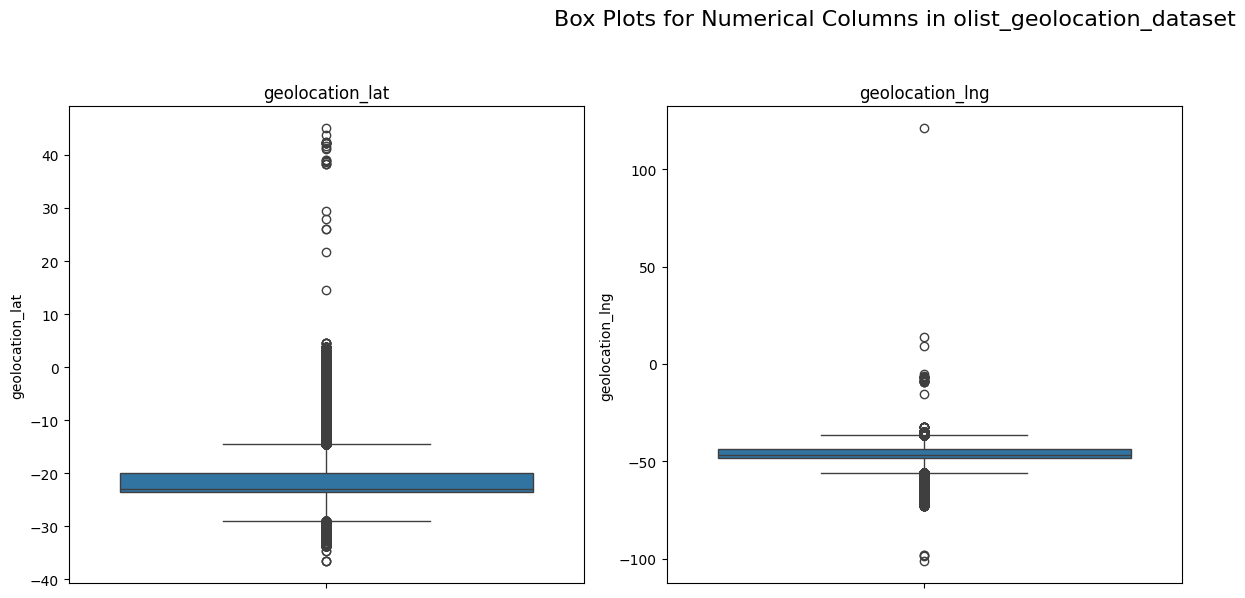


Analyzing DataFrame: olist_order_items_dataset


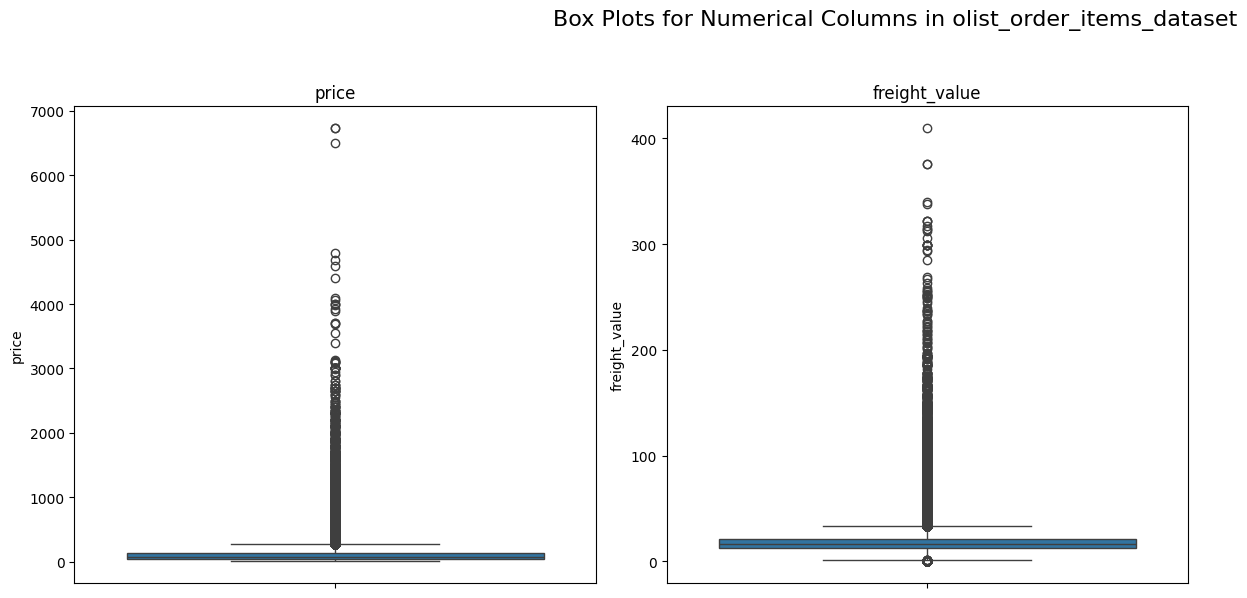


Analyzing DataFrame: olist_order_payments_dataset


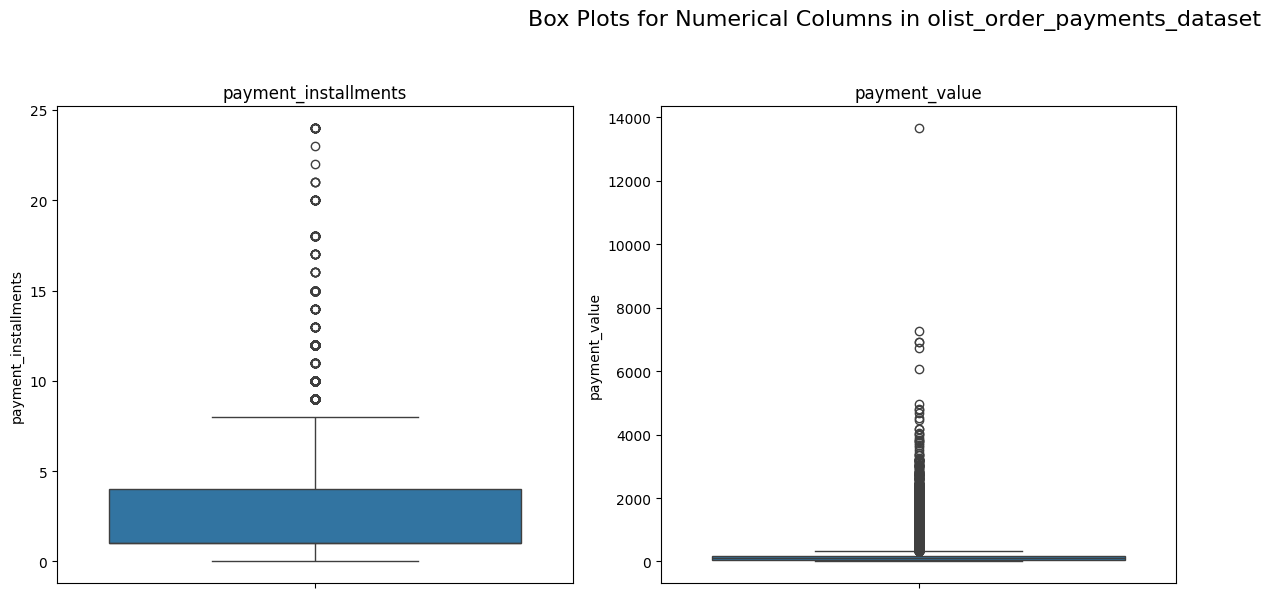


Analyzing DataFrame: olist_order_reviews_dataset


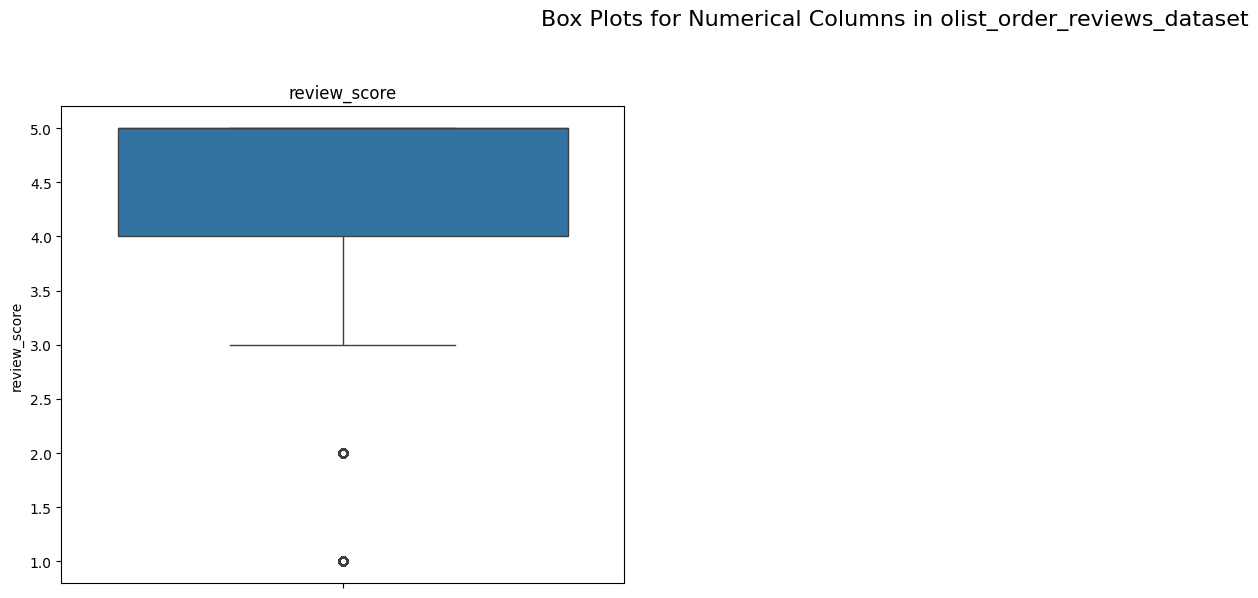


Analyzing DataFrame: olist_orders_dataset
No suitable numerical columns found in olist_orders_dataset for box plot analysis.

Analyzing DataFrame: olist_products_dataset


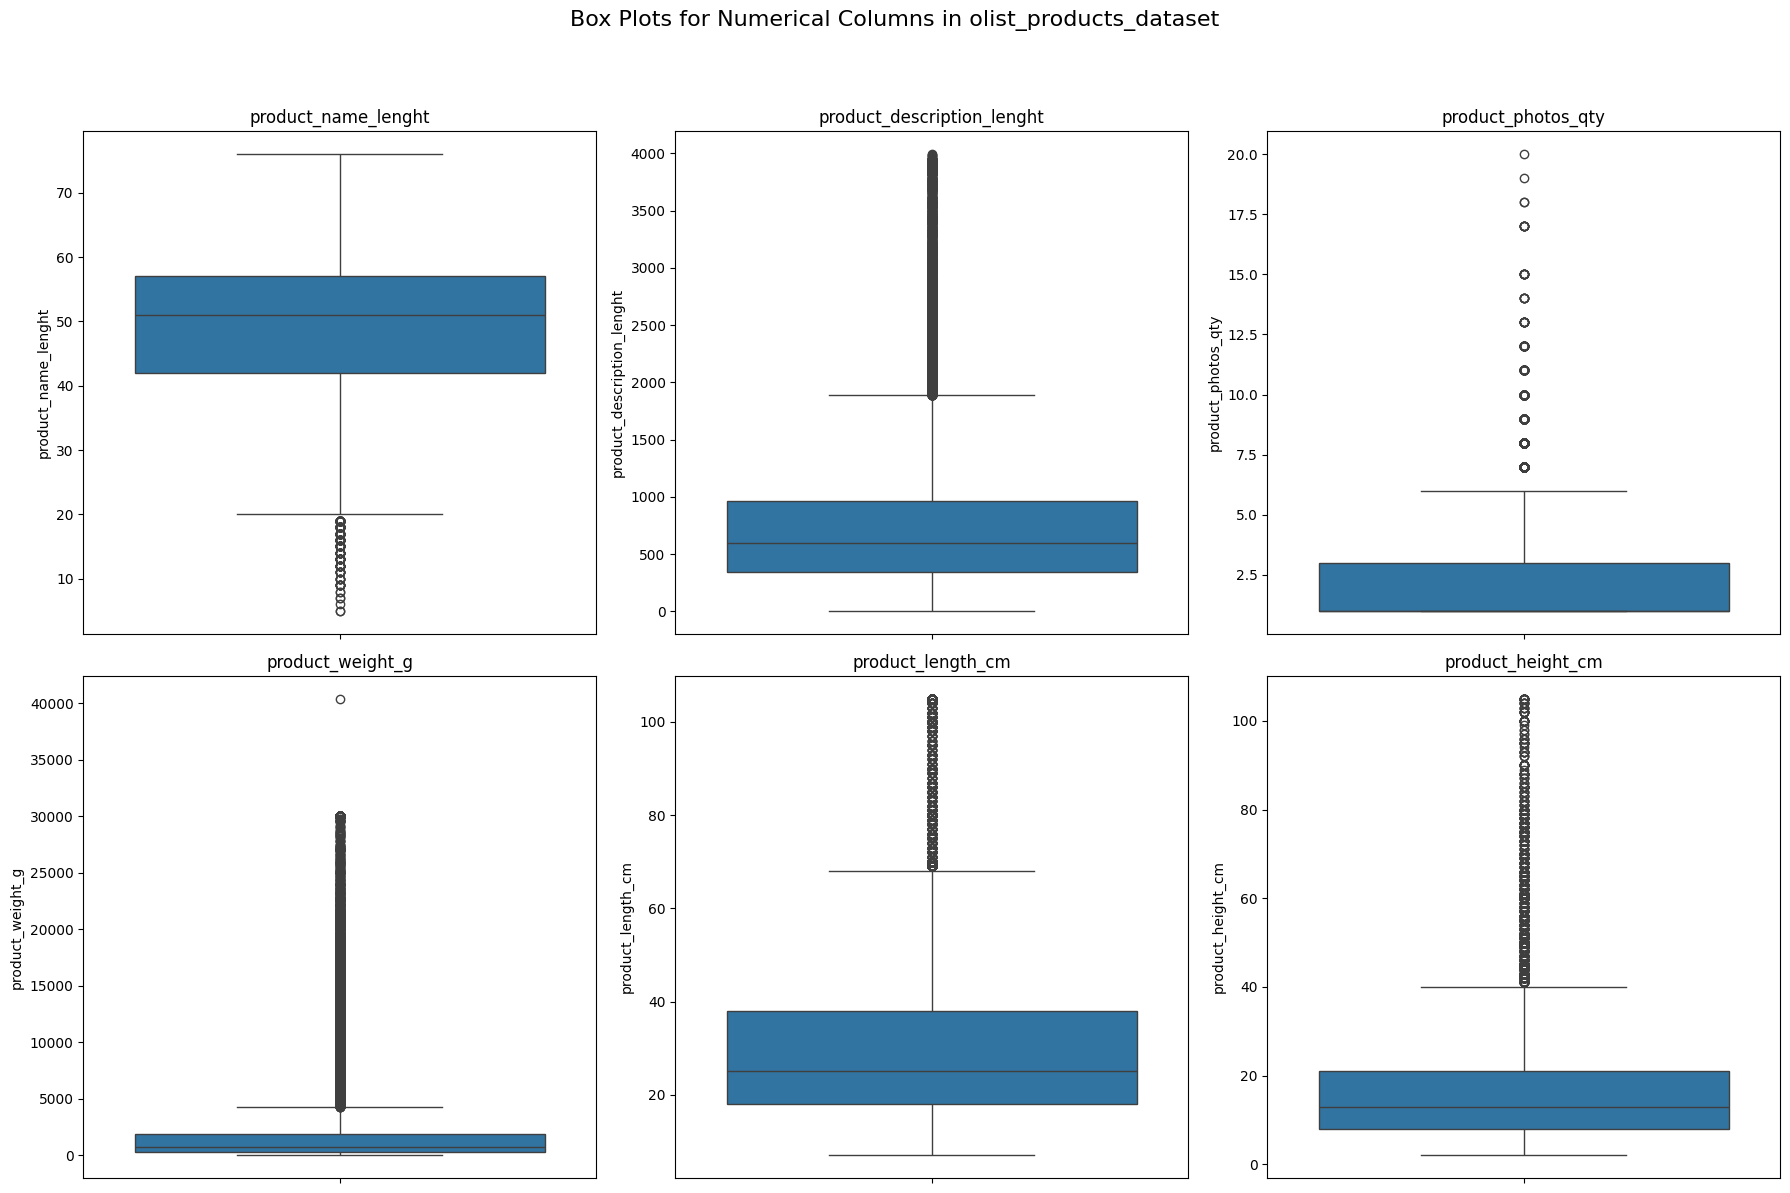


Analyzing DataFrame: olist_sellers_dataset
No suitable numerical columns found in olist_sellers_dataset for box plot analysis.

Analyzing DataFrame: product_category_name_translation
No suitable numerical columns found in product_category_name_translation for box plot analysis.

--- Visualizing Outliers with Box Plots for Marketing Funnel Datasets ---

Analyzing DataFrame: olist_marketing_qualified_leads_dataset
No suitable numerical columns found in olist_marketing_qualified_leads_dataset for box plot analysis.

Analyzing DataFrame: olist_closed_deals_dataset


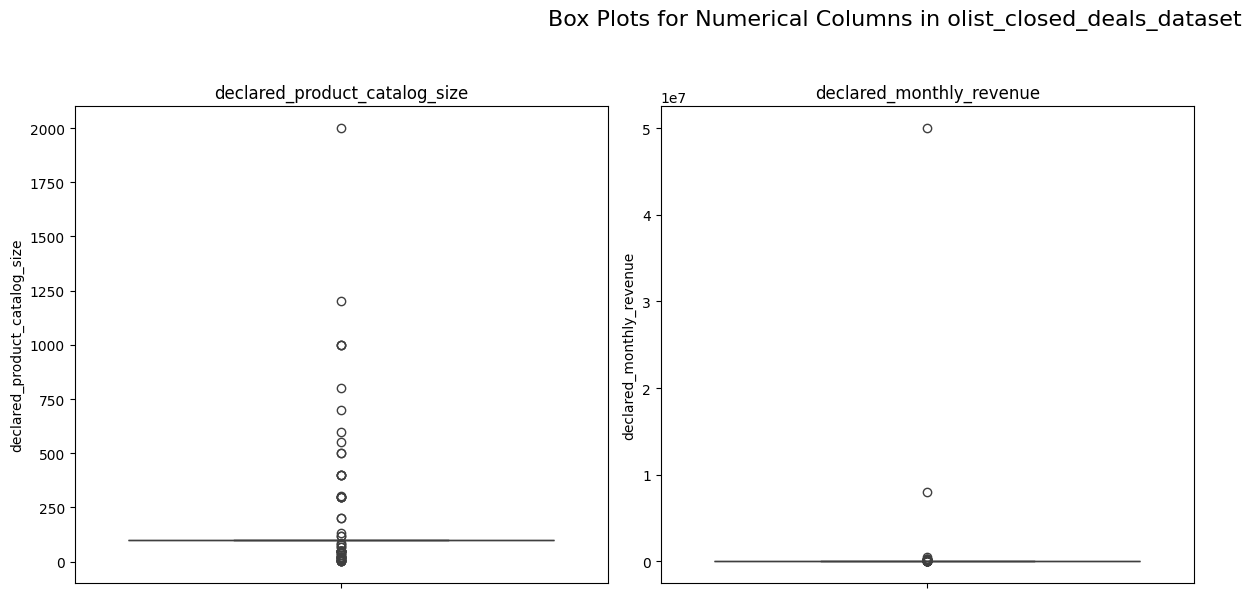


--- Visualizing Outliers with Box Plots for AI Generated Data DataFrame ---

Analyzing DataFrame: ai_gen_df


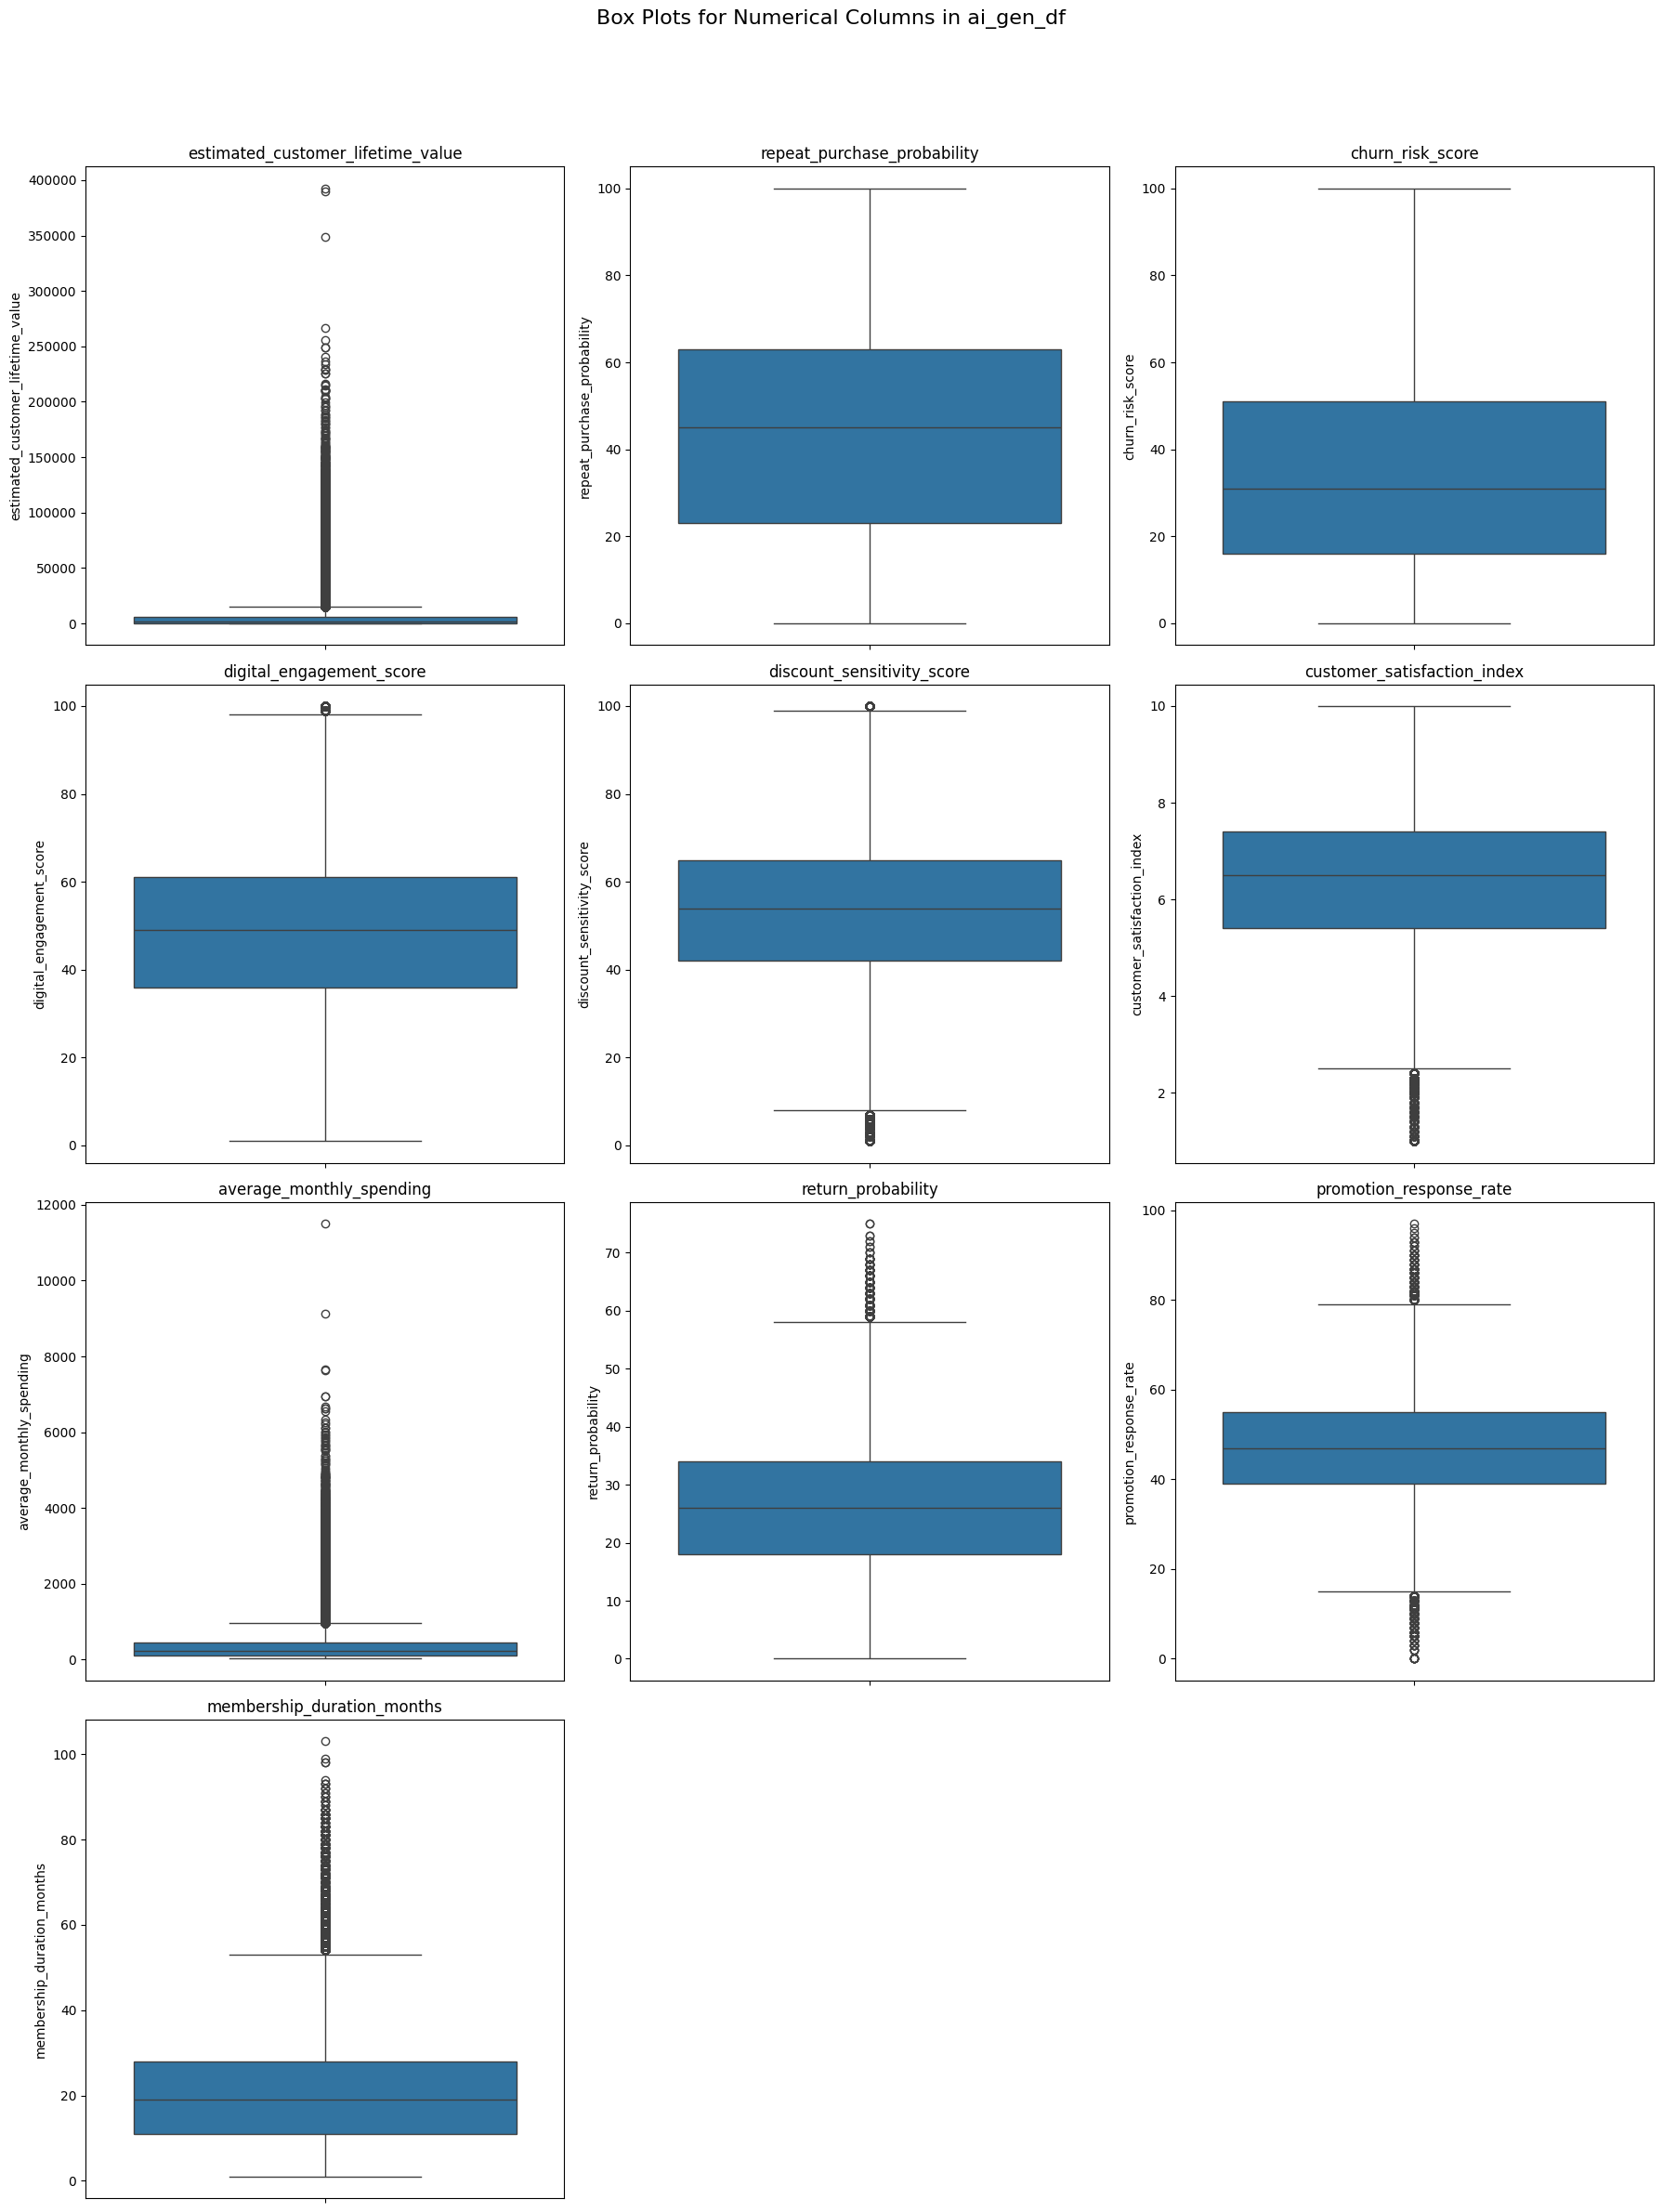


--- All outlier visualizations complete. ---


In [32]:
def plot_numerical_boxplots(df_dict, collection_name):
    """
    Plots box plots for numerical columns in a dictionary of DataFrames to visualize outliers.

    Args:
        df_dict (dict): A dictionary where keys are DataFrame names (str)
                        and values are pandas DataFrames.
        collection_name (str): The name of the collection of DataFrames (e.g., 'Brazilian E-commerce').
    """
    print(f"\n--- Visualizing Outliers with Box Plots for {collection_name} ---")
    for df_name, df in df_dict.items():
        print(f"\nAnalyzing DataFrame: {df_name}")

        numerical_cols = []
        for col in df.select_dtypes(include=np.number).columns:
            # Heuristic to exclude ID-like columns and zip codes
            if 'id' not in col.lower() and 'zip_code_prefix' not in col.lower() and 'sequential' not in col.lower():
                numerical_cols.append(col)

        if not numerical_cols:
            print(f"No suitable numerical columns found in {df_name} for box plot analysis.")
            continue

        # Determine optimal subplot grid based on number of columns
        n_cols_to_plot = len(numerical_cols)
        n_rows = max(1, (n_cols_to_plot + 2) // 3) # Roughly 3 columns per row

        plt.figure(figsize=(18, max(5, n_rows * 6))) # Adjust figure size dynamically
        plt.suptitle(f'Box Plots for Numerical Columns in {df_name}', fontsize=16, y=1.02)

        for i, col in enumerate(numerical_cols, 1):
            plt.subplot(n_rows, 3, i)
            sns.boxplot(y=df[col].dropna())
            plt.title(f'{col}')
            plt.ylabel(col)

        plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
        plt.show()

print("--- Initiating Outlier Visualization Across All Datasets ---")

# Call the function for each dataset collection
plot_numerical_boxplots(dfs, "Brazilian E-commerce Datasets")
plot_numerical_boxplots(dfs_marketing_funnel, "Marketing Funnel Datasets")
plot_numerical_boxplots({'ai_gen_df': ai_gen_df}, "AI Generated Data DataFrame")

print("\n--- All outlier visualizations complete. ---")

### Deal with the massive Outlier

In [33]:
df[['declared_monthly_revenue']].describe(percentiles=[0.95,0.99])

,declared_monthly_revenue
count,8.420000e+02
mean,7.337768e+04
std,1.744799e+06
min,0.000000e+00
50%,0.000000e+00
95%,3.850000e+03
99%,1.918000e+05
max,5.000000e+07


In [34]:
#is the seller exist?
dfs['olist_sellers_dataset'][
    dfs['olist_sellers_dataset']['seller_id']
    ==
    '6fcc97197c64771f3c18aea3aa9d3913'
]

,seller_id,seller_zip_code_prefix,seller_city,seller_state


In [35]:
#how many order items
dfs['olist_order_items_dataset'][
    dfs['olist_order_items_dataset']['seller_id']
    ==
    '6fcc97197c64771f3c18aea3aa9d3913'
]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [36]:
closed_deals_df.sort_values(
    'declared_monthly_revenue',
    ascending=False
)[
    ['seller_id', 'business_segment', 'declared_monthly_revenue']
].head(20)

,seller_id,business_segment,declared_monthly_revenue
188,6fcc97197c64771f3c18aea3aa9d3913,construction_tools_house_garden,50000000.0
408,9966324e28b7fa38165d2d3d12d53b7f,phone_mobile,8000000.0
681,c33e6d3ad32fd5bec1b0f2522f668213,other,500000.0
589,157497483bb7876340ea4441c9bd1774,pet,300000.0
605,7c7d0dee362960b1d9b01fe7284e19ba,home_decor,300000.0
813,0d7d5bca59d45d750fb7913b974e9d08,construction_tools_house_garden,250000.0
392,8c6d188ef073e289887bc52bc37f3e61,audio_video_electronics,250000.0
236,366b6b05f39997f102dc5179de14d43c,health_beauty,210000.0
838,4a82eab98441aeb64566e2776c1fb2b6,construction_tools_house_garden,200000.0
59,5181ea7b0d346ed14c5c07f0ff22b2b4,toys,180000.0


It is an outlier because the seller id is not registered.

In [37]:
print("Removing outlier from closed_deals_df...")

# Remove the identified outlier row(s) from closed_deals_df
# We'll create a new DataFrame excluding the row(s) where declared_monthly_revenue is 50,000,000
closed_deals_df = dfs_marketing_funnel['olist_closed_deals_dataset']
closed_deals_df = closed_deals_df[
    ~((closed_deals_df['declared_monthly_revenue'] == 50000000.0) &
      (closed_deals_df['business_segment'] == 'construction_tools_house_garden'))
]

# Update the DataFrame in the dictionary
dfs_marketing_funnel['olist_closed_deals_dataset'] = closed_deals_df

print("Outlier row(s) removed. Displaying top 20 declared_monthly_revenue after removal:")
display(closed_deals_df.sort_values(
    'declared_monthly_revenue',
    ascending=False
)[
    ['seller_id', 'business_segment', 'declared_monthly_revenue']
].head())

Removing outlier from closed_deals_df...
Outlier row(s) removed. Displaying top 20 declared_monthly_revenue after removal:


,seller_id,business_segment,declared_monthly_revenue
408,9966324e28b7fa38165d2d3d12d53b7f,phone_mobile,8000000.0
681,c33e6d3ad32fd5bec1b0f2522f668213,other,500000.0
605,7c7d0dee362960b1d9b01fe7284e19ba,home_decor,300000.0
589,157497483bb7876340ea4441c9bd1774,pet,300000.0
813,0d7d5bca59d45d750fb7913b974e9d08,construction_tools_house_garden,250000.0


An extreme outlier in declared monthly revenue was identified during numerical EDA. Cross-dataset validation revealed that the associated seller_id did not exist in the seller transaction dataset. Therefore, the row was removed due to inconsistency and high risk of distorting analysis.”

## Relationship Analysis

delivery_delay vs review_score
payment_value vs installments
freight_value vs review sentiment

--- Starting Relationship Analysis ---

Analyzing Delivery Delay vs Review Score...


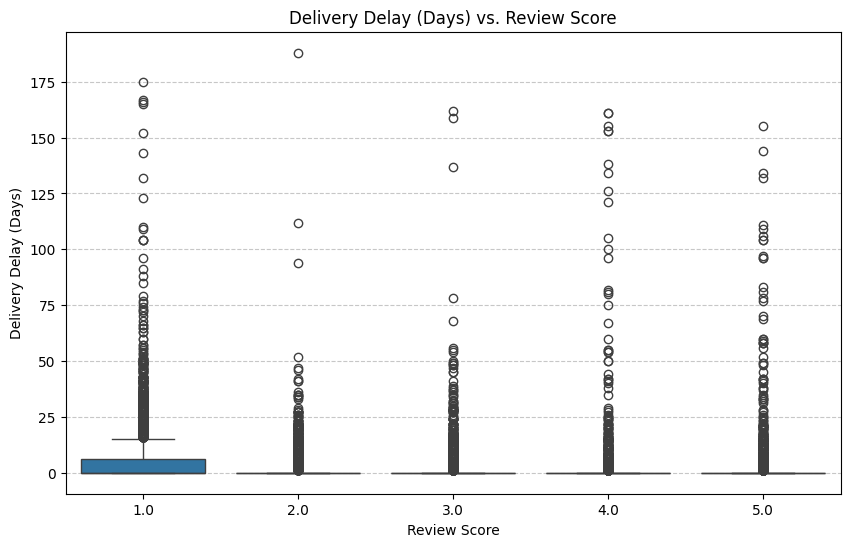


Analyzing Payment Value vs Installments...


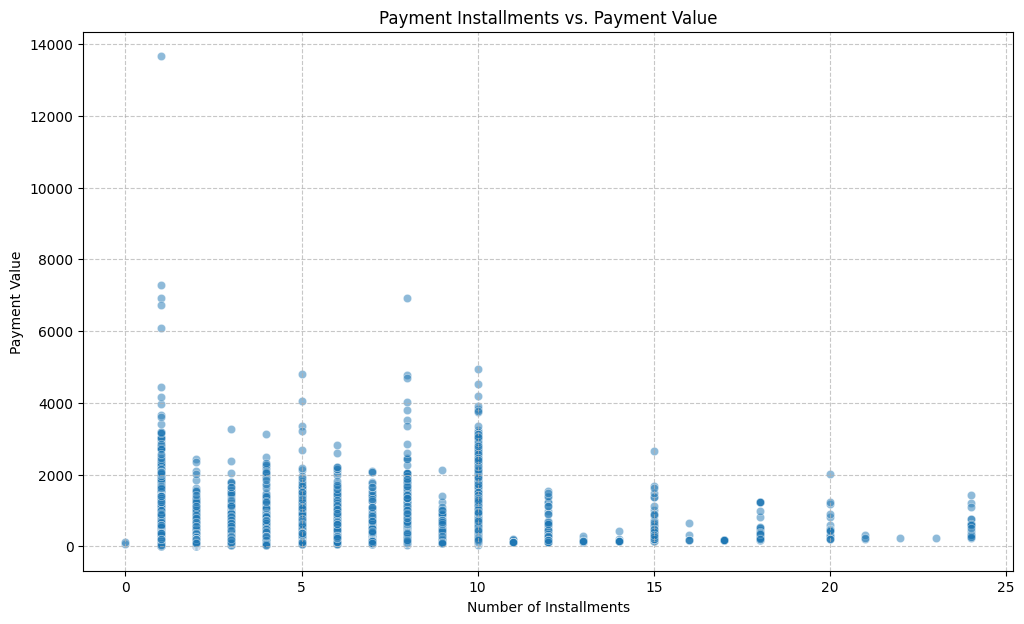

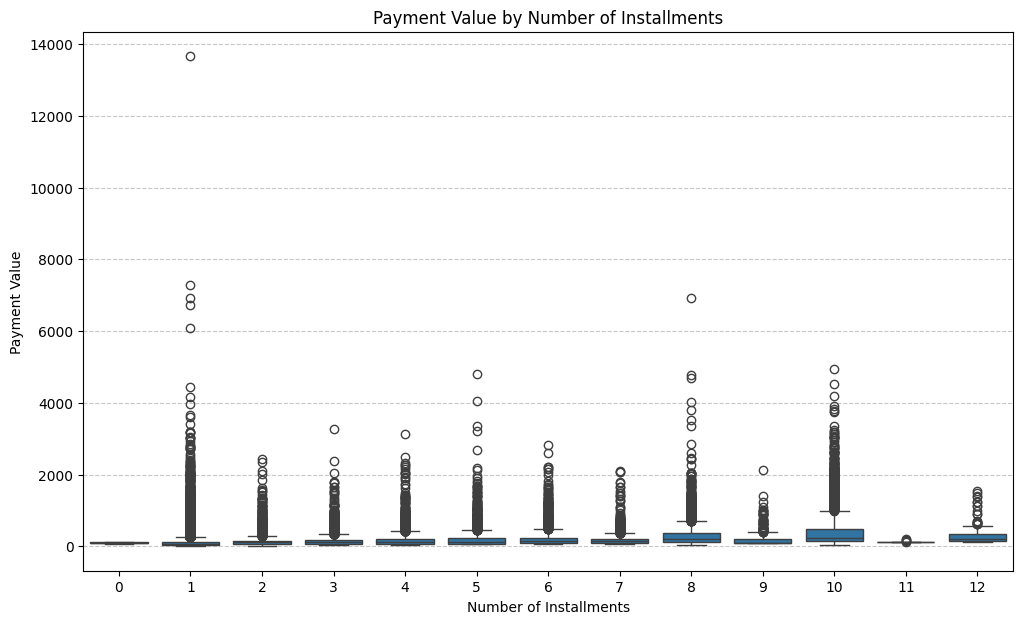


Analyzing Freight Value vs Review Sentiment...


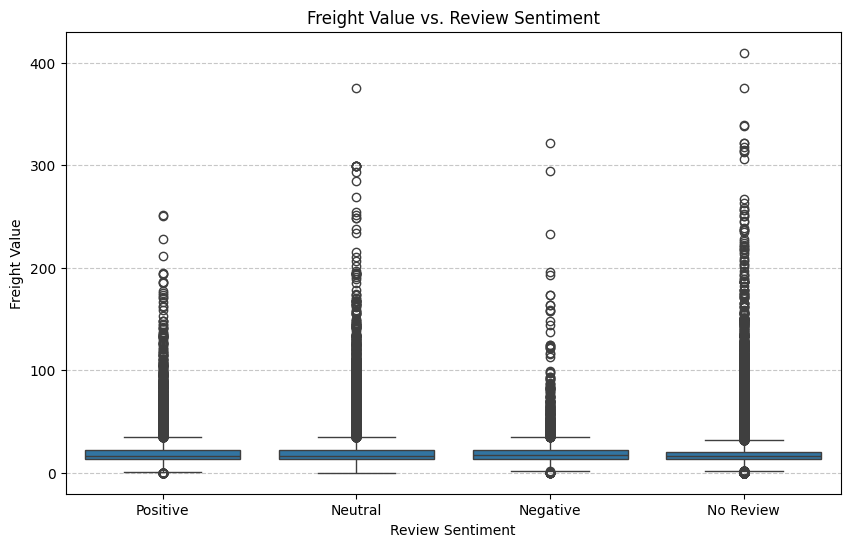

--- Relationship Analysis Complete ---


In [38]:
print("--- Starting Relationship Analysis ---")

# --- 1. Delivery Delay vs Review Score ---
print("\nAnalyzing Delivery Delay vs Review Score...")

# Merge orders and reviews datasets
orders_reviews_df = pd.merge(
    dfs['olist_orders_dataset'],
    dfs['olist_order_reviews_dataset'],
    on='order_id',
    how='left'
)

# Convert timestamp columns to datetime
orders_reviews_df['order_delivered_customer_date'] = pd.to_datetime(orders_reviews_df['order_delivered_customer_date'])
orders_reviews_df['order_estimated_delivery_date'] = pd.to_datetime(orders_reviews_df['order_estimated_delivery_date'])

# Calculate delivery delay (in days). If delivered early, delay is 0.
orders_reviews_df['delivery_delay_days'] = (orders_reviews_df['order_delivered_customer_date'] - orders_reviews_df['order_estimated_delivery_date']).dt.days
orders_reviews_df['delivery_delay_days'] = orders_reviews_df['delivery_delay_days'].apply(lambda x: max(0, x) if pd.notna(x) else np.nan)

# Filter out rows where review_score or delivery_delay_days are missing for this analysis
delivery_review_analysis_df = orders_reviews_df.dropna(subset=['review_score', 'delivery_delay_days'])

# Plot: Box plot of Delivery Delay by Review Score
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_score', y='delivery_delay_days', data=delivery_review_analysis_df)
plt.title('Delivery Delay (Days) vs. Review Score')
plt.xlabel('Review Score')
plt.ylabel('Delivery Delay (Days)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 2. Payment Value vs Installments ---
print("\nAnalyzing Payment Value vs Installments...")

payments_df = dfs['olist_order_payments_dataset']

# Plot: Scatter plot of Payment Installments vs Payment Value
plt.figure(figsize=(12, 7))
sns.scatterplot(x='payment_installments', y='payment_value', data=payments_df, alpha=0.5)
plt.title('Payment Installments vs. Payment Value')
plt.xlabel('Number of Installments')
plt.ylabel('Payment Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plot: Box plot of Payment Value by Installments
# Limit installments to a reasonable range for better visualization if there are extreme outliers
payments_filtered_df = payments_df[payments_df['payment_installments'] <= 12] # Assuming most common installments are up to 12
plt.figure(figsize=(12, 7))
sns.boxplot(x='payment_installments', y='payment_value', data=payments_filtered_df)
plt.title('Payment Value by Number of Installments')
plt.xlabel('Number of Installments')
plt.ylabel('Payment Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 3. Freight Value vs Review Sentiment ---
print("\nAnalyzing Freight Value vs Review Sentiment...")

# Merge order items and reviews datasets
order_items_reviews_df = pd.merge(
    dfs['olist_order_items_dataset'],
    dfs['olist_order_reviews_dataset'],
    on='order_id',
    how='left'
)

# Filter out rows where freight_value or review_sentiment are missing
freight_sentiment_analysis_df = order_items_reviews_df.dropna(subset=['freight_value', 'review_sentiment'])

# Plot: Box plot of Freight Value by Review Sentiment
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_sentiment', y='freight_value', data=freight_sentiment_analysis_df, order=['Positive', 'Neutral', 'Negative', 'No Review'])
plt.title('Freight Value vs. Review Sentiment')
plt.xlabel('Review Sentiment')
plt.ylabel('Freight Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("--- Relationship Analysis Complete ---")

## Statistical Summary

In [41]:
def analyze_numerical_columns_with_advanced_stats(df_dict, collection_name):
    """
    Analyzes and displays comprehensive descriptive statistics (mean, median, mode, SD, skewness, variance)
    for numerical columns in a dictionary of DataFrames.

    Args:
        df_dict (dict): A dictionary where keys are DataFrame names (str)
                        and values are pandas DataFrames.
        collection_name (str): The name of the collection of DataFrames (e.g., 'Brazilian E-commerce').
    """
    print(f"\n--- Comprehensive Numerical Feature Analysis for {collection_name} ---")
    for df_name, df in df_dict.items():
        print(f"\nAnalyzing DataFrame: {df_name}")

        numerical_cols = []
        for col in df.select_dtypes(include=np.number).columns:
            # Heuristic to exclude ID-like columns, zip codes, and sequential counters, which are numerical but often nominal or identifiers
            if 'id' not in col.lower() and 'zip_code_prefix' not in col.lower() and 'sequential' not in col.lower():
                numerical_cols.append(col)

        if not numerical_cols:
            print(f"No suitable numerical columns found in {df_name} for statistical analysis.")
            continue

        for col in numerical_cols:
            print(f"\n--- Statistics for '{col}' in {df_name} ---")
            series = df[col].dropna() # Drop NaN values for accurate statistics

            if not series.empty:
                print(f"Count: {len(series)}")
                print(f"Mean: {series.mean():.2f}")
                print(f"Median: {series.median():.2f}")
                modes = series.mode()
                print(f"Mode: {', '.join([f'{m:.2f}' for m in modes]) if not modes.empty else 'N/A'}")
                print(f"Standard Deviation (SD): {series.std():.2f}")
                print(f"Variance: {series.var():.2f}")
                print(f"Skewness: {series.skew():.2f}")
                print(f"Min: {series.min():.2f}")
                print(f"Max: {series.max():.2f}")
            else:
                print(f"Column '{col}' has no non-missing numerical values to analyze.")

print("--- Initiating Comprehensive Numerical Feature Analysis Across All Datasets ---")

# Call the function for each dataset collection
analyze_numerical_columns_with_advanced_stats(dfs, "Brazilian E-commerce Datasets")
analyze_numerical_columns_with_advanced_stats(dfs_marketing_funnel, "Marketing Funnel Datasets")
analyze_numerical_columns_with_advanced_stats({'ai_gen_df': ai_gen_df}, "AI Generated Data DataFrame")

print("\n--- All comprehensive numerical feature analyses complete. ---")


--- Initiating Comprehensive Numerical Feature Analysis Across All Datasets ---

--- Comprehensive Numerical Feature Analysis for Brazilian E-commerce Datasets ---

Analyzing DataFrame: olist_customers_dataset
No suitable numerical columns found in olist_customers_dataset for statistical analysis.

Analyzing DataFrame: olist_geolocation_dataset

--- Statistics for 'geolocation_lat' in olist_geolocation_dataset ---
Count: 1000163
Mean: -21.18
Median: -22.92
Mode: -27.10
Standard Deviation (SD): 5.72
Variance: 32.67
Skewness: 1.57
Min: -36.61
Max: 45.07

--- Statistics for 'geolocation_lng' in olist_geolocation_dataset ---
Count: 1000163
Mean: -46.39
Median: -46.64
Mode: -48.63
Standard Deviation (SD): 4.27
Variance: 18.23
Skewness: -0.10
Min: -101.47
Max: 121.11

Analyzing DataFrame: olist_order_items_dataset

--- Statistics for 'price' in olist_order_items_dataset ---
Count: 112650
Mean: 120.65
Median: 74.99
Mode: 59.90
Standard Deviation (SD): 183.63
Variance: 33721.42
Skewness: 7.92
